# Dexed dataset audit

Explore the Dexed dataset: link audio to preset parameters, extract descriptors, and build coverage maps of the behaviour space -- ending with the exact 38-feature space (6 ACTM + 32 TT) used by SpinVAE2's timbre loss.

## Sommaire

1. [Setup and data loading](#1.-Setup-and-data-loading)
2. [Single preset exploration](#2.-Single-preset-exploration)
3. [Quick audio descriptors (librosa)](#3.-Quick-audio-descriptors-(librosa))
4. [Perceptual descriptors: TimbreToolbox + AudioCommons](#4.-Perceptual-descriptors:-TimbreToolbox-+-AudioCommons)
5. [Coverage map in the canonical Z space (38 features)](#5.-Coverage-map-in-the-canonical-Z-space-(38-features))
6. [Categorising presets by name](#6.-Categorising-presets-by-name)
7. [Automatic clustering (K-means) vs name-based categories](#7.-Automatic-clustering-(K-means)-vs-name-based-categories)
8. [Semantic vs spectral descriptor comparison](#8.-Semantic-vs-spectral-descriptor-comparison)
9. [Quantifying UMAP coverage](#9.-Quantifying-UMAP-coverage)
10. [Coverage map in the raw parameter space (Θ)](#10.-Coverage-map-in-the-raw-parameter-space-(%CE%98))
11. [Native 38D coverage metrics and alternative projections](#11.-Native-38D-coverage-metrics-and-alternative-projections)
12. [Summary of results so far](#12.-Summary-of-results-so-far)
13. [Export presets for local listening](#13.-Export-presets-for-local-listening)
14. [Investigating the detached UMAP cluster](#14.-Investigating-the-detached-UMAP-cluster)
15. [Next steps](#15.-Next-steps)


## 1. Setup and data loading

In [128]:
import os, sys, glob, re
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH','')

PROJECT_ROOT = os.path.expanduser('~/projects/spinvae2')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATASET_ROOT = '/data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed'
AUDIO_DIR = os.path.join(DATASET_ROOT, 'Audio')
PITCH, VEL = 56, 75

print('Audio dir exists:', os.path.isdir(AUDIO_DIR))
print('Nb wav files   :', len(glob.glob(os.path.join(AUDIO_DIR, '*.wav'))))

Audio dir exists: True
Nb wav files   : 120580


In [129]:
from synth.dexed import PresetDfDatabase
from synth.dexed import Dexed

db = PresetDfDatabase()
print('Nb presets in DB:', db.nb_presets)

def wav_path(uid, variation=0, pitch=PITCH, vel=VEL):
    stem = f"{uid:06d}_pitch{pitch:03d}vel{vel:03d}_var{variation:03d}.wav"
    return os.path.join(AUDIO_DIR, stem)

def uid_from_filename(fname):
    m = re.match(r"(\d{6})_", os.path.basename(fname))
    return int(m.group(1)) if m else None

all_uids = list(db.all_preset_UIDs)
print('Example UID:', all_uids[0], '->', wav_path(all_uids[0]))

Nb presets in DB: 30145
Example UID: 0 -> /data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed/Audio/000000_pitch056vel075_var000.wav


### 1.1 Reusable plotting helper

In [161]:
def plot_2d(X, color, title, ax=None, s=4, alpha=0.5, cmap='viridis',
            colorbar_label=None, figsize=(9, 8)):
    """Generic scatter plot for a 2D projection (PCA/UMAP/t-SNE), used throughout
    this notebook so every map shares the same point size/alpha/layout conventions."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(X[:, 0], X[:, 1], c=color, s=s, cmap=cmap, alpha=alpha)
    ax.set_title(title)
    if colorbar_label:
        plt.colorbar(sc, ax=ax, label=colorbar_label)
    if standalone:
        plt.tight_layout(); plt.show()
    return sc


## 2. Single preset exploration

UID 0  |  BRITE RDS  (INCONI19)  |  var0


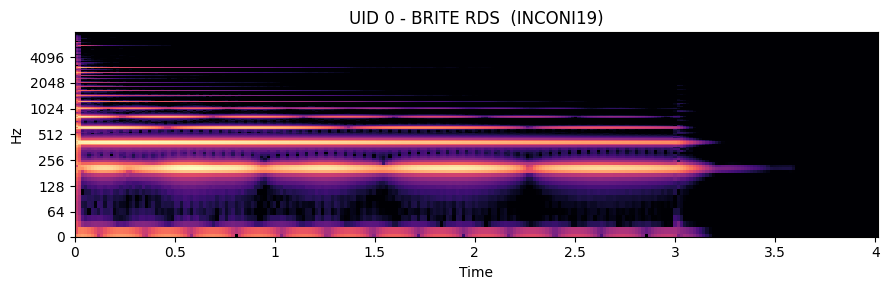

In [130]:
def explore_preset(uid, variation=0):
    name = db.get_preset_name(uid, long_name=True)
    path = wav_path(uid, variation)
    audio, sr = sf.read(path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    print(f"UID {uid}  |  {name}  |  var{variation}")
    S = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=1024, hop_length=256)), ref=np.max)
    fig, ax = plt.subplots(figsize=(9,3))
    librosa.display.specshow(S, sr=sr, hop_length=256, x_axis='time', y_axis='log', ax=ax)
    ax.set_title(f"UID {uid} - {name}")
    plt.tight_layout(); plt.show()
    display(Audio(audio, rate=sr))

explore_preset(all_uids[0])

## 3. Quick audio descriptors (librosa)

Generic audio features, computed quickly on a sample -- a first, rough look before using the perceptually-grounded 38-feature space (section 5).

In [131]:
def compute_librosa_descriptors(audio, sr):
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if np.abs(audio).max() < 1e-6:
        return None
    feats = {}
    S = np.abs(librosa.stft(audio, n_fft=1024, hop_length=256))
    feats['centroid']  = float(np.mean(librosa.feature.spectral_centroid(S=S, sr=sr)))
    feats['bandwidth'] = float(np.mean(librosa.feature.spectral_bandwidth(S=S, sr=sr)))
    feats['rolloff']   = float(np.mean(librosa.feature.spectral_rolloff(S=S, sr=sr)))
    feats['flatness']  = float(np.mean(librosa.feature.spectral_flatness(S=S)))
    feats['rms']       = float(np.mean(librosa.feature.rms(S=S)))
    return feats

## 4. Perceptual descriptors: TimbreToolbox + AudioCommons

SpinVAE2's timbre loss uses **TimbreToolbox (TT)** and **AudioCommons Timbral Models (ACTM)** features, from
which an unsupervised correlation-based selection keeps 32 TT + 6 ACTM = **38 features** (`a in R^38` in the paper).

TT requires MATLAB (available on `bonsho`, not on `gottan`). The dataset's timbre features are computed via
`ds.compute_and_store_timbre_features()`, which writes `raw_timbre_features.df.pickle` -- loaded below.

In [132]:
import pathlib
from utils.timbrefeatures import TimbreFeatures, parse_timbre_features_arguments

raw_pickle = pathlib.Path(DATASET_ROOT) / 'raw_timbre_features.df.pickle'
raw_df = pd.read_pickle(raw_pickle)
print('Raw shape:', raw_df.shape)
print('Presets couverts:', raw_df['preset_UID'].nunique())

Raw shape: (241160, 97)
Presets couverts: 30145


In [133]:
# Apply the exact SpinVAE2 paper selection: log-scale + z-score normalisation (TimbreFeatures),
# then keep only the 38 features surviving the >0.9 correlation filter.
tf = TimbreFeatures(raw_pickle)
selected_38 = parse_timbre_features_arguments(['ac_*', 'tt_*', '__no_high_corr__'])
ac_38 = [f for f in selected_38 if f.startswith('ac_')]
tt_38 = [f for f in selected_38 if f.startswith('tt_')]
print(f'ACTM: {len(ac_38)} (papier: 6)')
print(f'TT: {len(tt_38)} (papier: 32)')

behaviour_df = tf.postproc_df[['preset_UID', 'variation'] + selected_38].copy()
behaviour_df = behaviour_df[behaviour_df['variation'] == 0].set_index('preset_UID')
print('Behaviour space (var0 only):', behaviour_df.shape)

ACTM: 6 (papier: 6)
TT: 32 (papier: 32)
Behaviour space (var0 only): (30145, 39)


## 5. Coverage map in the canonical Z space (38 features)

This is the actual behaviour space $Z$ used by SpinVAE2's timbre loss -- the map future IMGEP exploration will
be compared against.

### 5.1 PCA

Explained variance (2 PCs): 0.46047395754701315


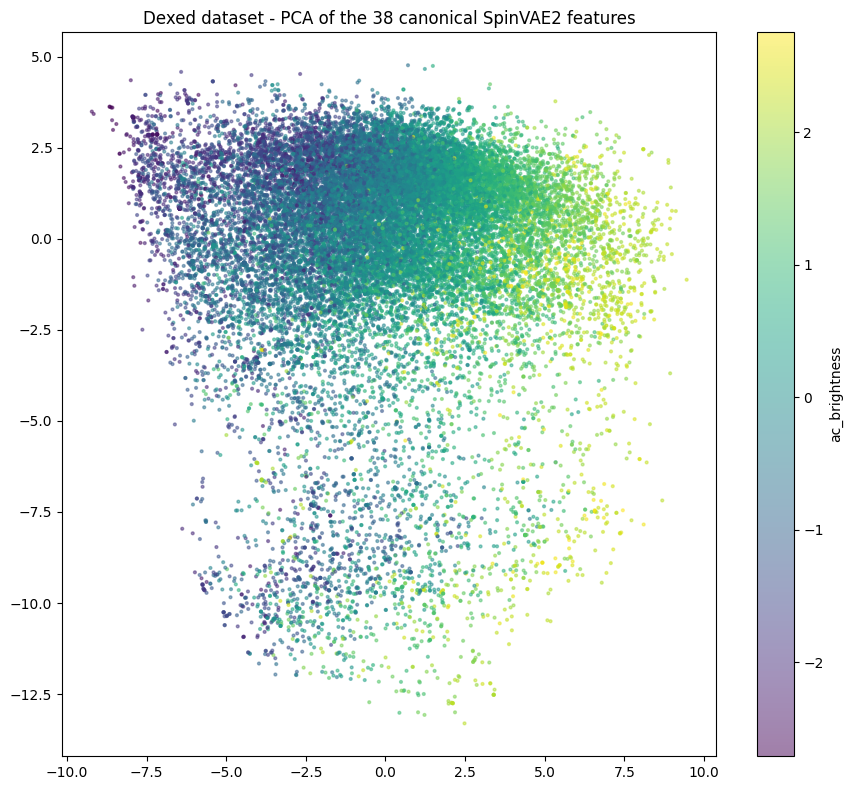

In [162]:
from sklearn.decomposition import PCA

X38 = np.nan_to_num(behaviour_df[selected_38].values)
pca38 = PCA(n_components=2)
X38p = pca38.fit_transform(X38)
print('Explained variance (2 PCs):', pca38.explained_variance_ratio_[:2].sum())

plot_2d(X38p, behaviour_df['ac_brightness'],
        'Dexed dataset - PCA of the 38 canonical SpinVAE2 features',
        colorbar_label='ac_brightness')


### 5.2 UMAP

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


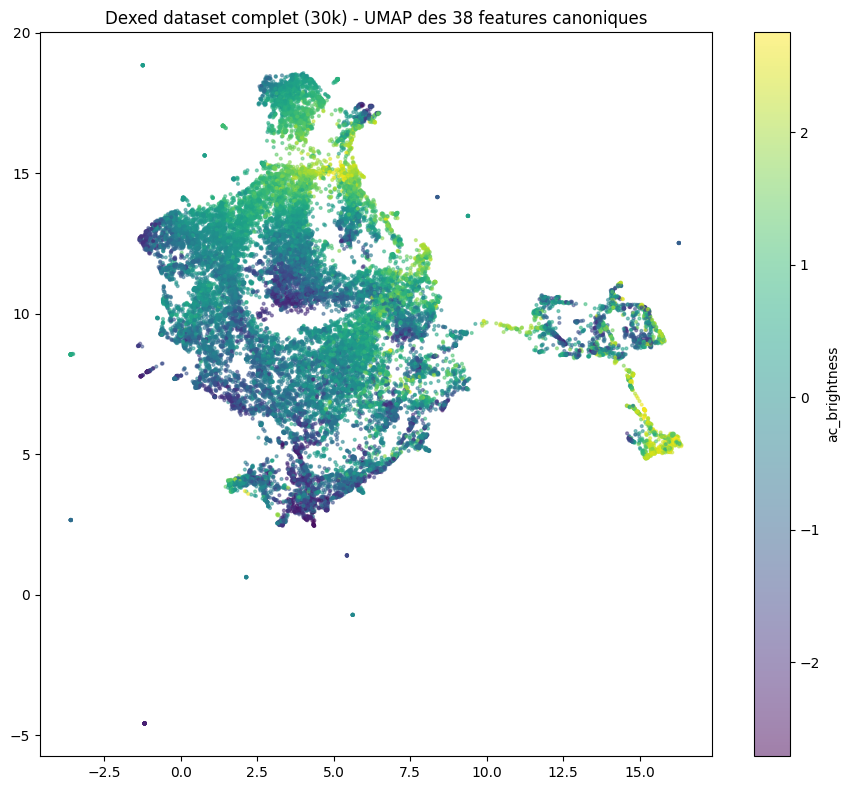

In [163]:
try:
    import sys
    sys.modules['umap.parametric_umap'] = None  # empêche l'import qui plante
    import umap
    reducer38 = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
    X38u = reducer38.fit_transform(X38)

    plot_2d(X38u, behaviour_df['ac_brightness'],
            'Dexed dataset complet (30k) - UMAP des 38 features canoniques',
            colorbar_label='ac_brightness')
    behaviour_df['umap_x'], behaviour_df['umap_y'] = X38u[:,0], X38u[:,1]
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
behaviour_df['pca_x'], behaviour_df['pca_y'] = X38p[:,0], X38p[:,1]


### 5.3 Interactive exploration (click to listen, coloured by brightness)

In [136]:
import plotly.graph_objects as go
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import soundfile as sf

# Widget de sortie pour l'audio
audio_output = widgets.Output()

# Préparer les données pour Plotly
uids_list = list(behaviour_df.index)
names_list = [db.get_preset_name(uid) for uid in uids_list]

fig = go.FigureWidget(
    data=[go.Scatter(  # <-- Scatter au lieu de Scattergl
        x=X38u[:,0], y=X38u[:,1],
        mode='markers',
        marker=dict(size=4, color=behaviour_df['ac_brightness'], colorscale='Viridis', showscale=True),
        text=[f"UID {u}: {n}" for u, n in zip(uids_list, names_list)],
        hoverinfo='text'
    )],
    layout=go.Layout(width=800, height=700, title="Cliquer sur un point pour écouter le preset")
)

def on_click(trace, points, state):
    if points.point_inds:
        idx = points.point_inds[0]
        uid = uids_list[idx]
        name = names_list[idx]
        path = wav_path(uid, 0)
        with audio_output:
            clear_output(wait=True)
            print(f"UID {uid} - {name}")
            audio, sr = sf.read(path)
            display(Audio(audio, rate=sr))

fig.data[0].on_click(on_click)
display(fig)
display(audio_output)

FigureWidget({
    'data': [{'hoverinfo': 'text',
              'marker': {'color': {'bdata': ('Mx6qYf6X0L/kr8Bc2QzPP9oJ5m91XM' ... '5ux9D3v0Ua+JLgVd0/oAp5nHqe8z8='),
                                   'dtype': 'f8'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'showscale': True,
                         'size': 4},
              'mode': 'markers',
       

Output()

## 6. Categorising presets by name

### 6.1 Most frequent words (full dataset)

In [137]:
import re
from collections import Counter

names_all = {uid: db.get_preset_name(uid, long_name=False).upper() for uid in behaviour_df.index}

word_counter = Counter()
for name in names_all.values():
    words = re.findall(r'[A-Z]+', name)
    word_counter.update(words)

print("Mots les plus fréquents dans les noms de presets :")
for word, count in word_counter.most_common(80):
    print(f"  {word:15s} {count}")

Mots les plus fréquents dans les noms de presets :
  PIANO           1058
  BASS            1053
  E               824
  B               739
  A               716
  BRASS           542
  Y               463
  SYN             451
  STRINGS         377
  CLAV            334
  ORGAN           303
  S               278
  SYNTH           267
  BELL            260
  BS              247
  RHODES          238
  STRING          238
  PNO             229
  FLUTE           222
  LEAD            220
  HORN            208
  STR             205
  X               196
  BC              187
  DX              186
  M               176
  P               167
  F               167
  PAD             159
  HARP            159
  VOICE           158
  GUITAR          150
  PERC            147
  BRS             142
  C               139
  T               138
  D               135
  STRG            134
  ORG             129
  SOLO            128
  CELLO           128
  FM              118
  H               117
 

### 6.2 Category assignment (keyword-based)

In [138]:
import re

# Mots-clés courts et ambigus : ne matchent QUE comme token entier (évite BOMBS, BOTTOM, LAMBDA, BENS, STRAT...)
SHORT_AMBIGUOUS = {'HI', 'BD', 'ENS', 'STR', 'TOM', 'BS'}

categories = {
    'PIANO':    ['PIANO', 'PNO', 'STEINWAY', 'E.GRAND', 'ELECGRAND', 'ELEC GRAND', 'E GRAND', 'BABYGRAND', 'BABY GRAND'],
    'BASS':     ['BASS', 'BS', 'SYNBASS', 'FRETLESS'],
    'BRASS':    ['BRASS', 'BRS', 'HORN', 'TRUMPET', 'SYNBRASS', 'TROMBONE'],
    'STRINGS':  ['STRINGS', 'STRING', 'STR', 'STRG', 'CELLO', 'VIOLIN', 'VIOLA'],
    'ORGAN':    ['ORGAN', 'ORG', 'HAMMOND', 'HMND', 'LESLIE'],
    'BELL':     ['BELL', 'BELLS', 'CHIME', 'GONG'],
    'LEAD':     ['LEAD', 'SYNLEAD'],
    'PAD':      ['PAD'],
    'FLUTE':    ['FLUTE', 'PIPES', 'OBOE', 'CLARINET', 'PICCOLO'],
    'CLAV':     ['CLAV'],
    'RHODES':   ['RHODES', 'WURLITZER'],
    'GUITAR':   ['GUITAR', 'GUIT', 'GTR', 'STEEL', 'SITAR', 'KOTO'],
    'VOICE':    ['VOICE', 'CHOIR', 'VOX'],
    'HARP':     ['HARP'],
    'SAX':      ['SAX'],
    'DRUM':     ['DRUM', 'DRUMS', 'SIMMONS', 'SIMSNAR'],
    'PERC':     ['PERC', 'VIBE'],
    'SNARE':    ['SNARE', 'SNR'],
    'TOM':      ['TOM', 'TOMS'],
    'HIHAT':    ['HI', 'HAT'],
    'CLAP':     ['CLAP'],
    'MARIMBA':  ['MARIMBA'],
    'BLOCK':    ['BLOCK'],
    'KICK':     ['BD', 'KICK'],
    'ENSEMBLE': ['ENS', 'ORCH'],
    'SYNTH_VINTAGE': ['MOOG', 'PROPHET', 'OBERHEIM'],
    'SYNTH':    ['SYN', 'SYNTH'],  # en dernier : sinon capte SYNBASS/SYNBRASS/SYNLEAD avant les vraies catégories
}

def categorize(name):
    name_upper = name.upper()
    tokens = set(re.findall(r'[A-Z]+', name_upper))
    for cat, keywords in categories.items():
        for kw in keywords:
            if ' ' in kw or '.' in kw:
                # mots-clés multi-caractères spéciaux (ex: 'E.GRAND', 'ELEC GRAND') : test sur la chaîne complète
                if kw in name_upper:
                    return cat
            elif kw in SHORT_AMBIGUOUS:
                # mots courts à risque : token entier uniquement
                if kw in tokens:
                    return cat
            else:
                # mots assez longs et spécifiques : sous-chaîne OK (capture les mots composés collés, ex: GRANDBRASS)
                if kw in name_upper:
                    return cat
    return 'OTHER'

cat_labels = pd.Series({uid: categorize(names_all[uid]) for uid in behaviour_df.index}, name='category')
print(cat_labels.value_counts())
print(f"\nOTHER: {(cat_labels == 'OTHER').sum()} / {len(cat_labels)} = {100*(cat_labels == 'OTHER').mean():.1f}%")

print("\n--- Verification anti-regression ---")
test_cases = ['BOMBS AWAY', 'ABSTURZ', 'CHOR.STRAT', 'BOTTOMORGN', 'LAMBDA 2', 'UNCLE BENS',
              'CHINKBELLS', 'GRANDBRASS', 'GRANDCLAV', 'SYNBASS 1', 'PICKGUITAR', 'ATOMFAGOTT']
for name in test_cases:
    print(f"{name:20s} -> {categorize(name.upper())}")

OTHER            14499
PIANO             2106
BASS              1954
BRASS             1687
STRINGS           1590
SYNTH             1006
ORGAN              974
GUITAR             792
BELL               769
FLUTE              597
CLAV               594
VOICE              522
LEAD               359
RHODES             354
HARP               349
PERC               328
SYNTH_VINTAGE      312
DRUM               293
PAD                248
ENSEMBLE           244
SAX                159
HIHAT               97
MARIMBA             90
TOM                 66
SNARE               56
CLAP                40
BLOCK               35
KICK                25
Name: category, dtype: int64

OTHER: 14499 / 30145 = 48.1%

--- Verification anti-regression ---
BOMBS AWAY           -> OTHER
ABSTURZ              -> OTHER
CHOR.STRAT           -> OTHER
BOTTOMORGN           -> ORGAN
LAMBDA 2             -> OTHER
UNCLE BENS           -> OTHER
CHINKBELLS           -> BELL
GRANDBRASS           -> BRASS
GRANDCLAV           

### 6.3 Most frequent words among unclassified (OTHER) presets

In [139]:
# Regarder les mots les plus fréquents SPÉCIFIQUEMENT dans les presets classés OTHER
other_uids = cat_labels[cat_labels == 'OTHER'].index
other_names = [names_all[uid] for uid in other_uids]

other_word_counter = Counter()
for name in other_names:
    words = re.findall(r'[A-Z]+', name)
    other_word_counter.update(words)

print(f"Mots les plus fréquents parmi les {len(other_uids)} presets OTHER :")
for word, count in other_word_counter.most_common(60):
    print(f"{word:15s} {count}")

Mots les plus fréquents parmi les 14499 presets OTHER :
B               371
A               333
Y               297
S               165
E               149
DX              125
X               113
SOLO            103
P               102
I               93
ANALOG          90
F               87
SPLIT           85
D               80
SND             79
T               78
V               77
FM              76
M               76
AV              73
EFX             73
C               71
G               67
PI              63
EP              60
SPACE           60
BR              56
GRAND           55
ST              55
H               53
STG             52
NEW             52
PLUCK           52
THE             51
BC              51
CHORUS          50
CP              48
PPG             48
O               44
EFFECT          43
HM              42
L               42
BIG             39
IMAGE           39
ECHO            38
DIGI            38
ENSEMBLE        38
MS              37
R               36
ARP 

### 6.4 UMAP coloured by category

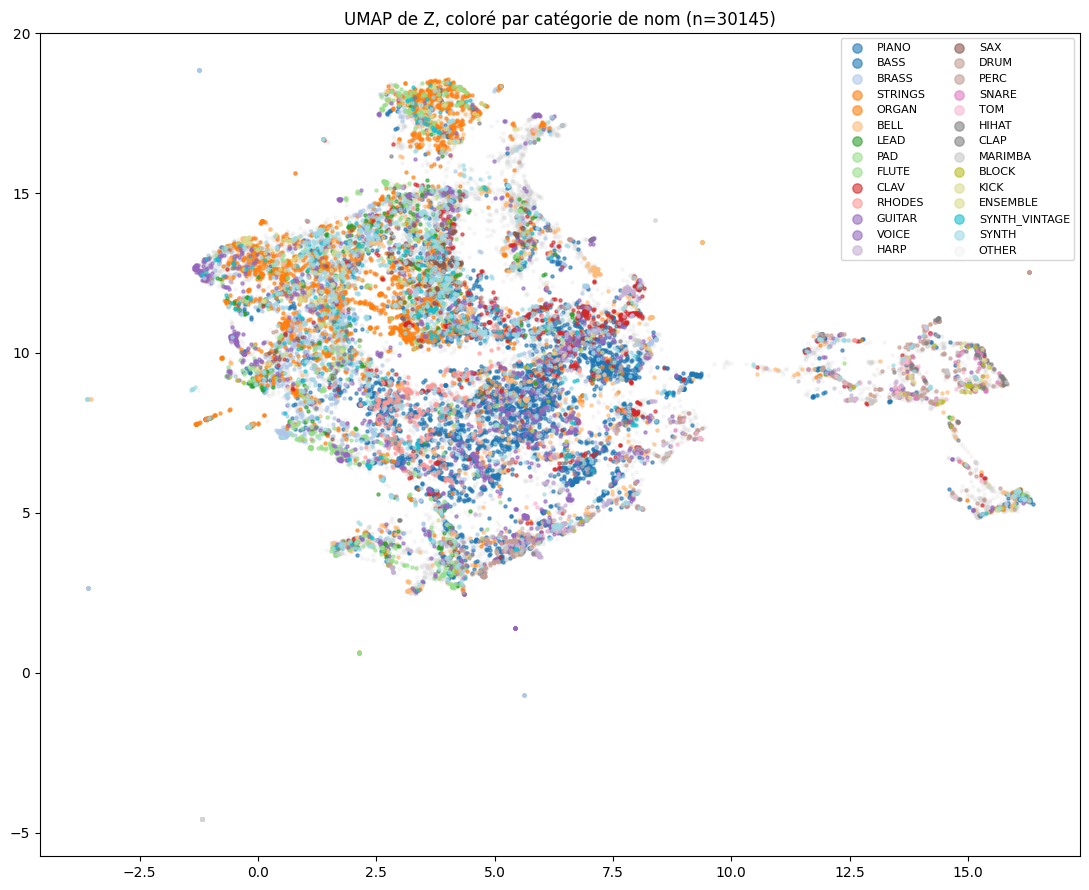

In [140]:
fig, ax = plt.subplots(figsize=(11,9))
palette = plt.cm.tab20(np.linspace(0, 1, len(categories)+1))
for i, cat in enumerate(list(categories.keys()) + ['OTHER']):
    mask = (cat_labels.reindex(behaviour_df.index) == cat).values
    color = 'lightgray' if cat == 'OTHER' else palette[i]
    zorder = 1 if cat == 'OTHER' else 2
    alpha = 0.15 if cat == 'OTHER' else 0.6
    ax.scatter(X38u[mask,0], X38u[mask,1], s=5, alpha=alpha, color=color, label=cat, zorder=zorder)
ax.legend(markerscale=3, loc='best', fontsize=8, ncol=2)
ax.set_title(f'UMAP de Z, coloré par catégorie de nom (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

### 6.5 Interactive exploration (click to listen, coloured by category)

In [141]:
import plotly.graph_objects as go
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import soundfile as sf
import matplotlib.colors as mcolors

audio_output = widgets.Output()

uids_list = list(behaviour_df.index)
names_list = [db.get_preset_name(uid) for uid in uids_list]
cat_array = cat_labels.reindex(behaviour_df.index).values

qualitative_colors = list(mcolors.TABLEAU_COLORS.values()) + list(plt.cm.Set1(np.linspace(0,1,9))) + list(plt.cm.Set3(np.linspace(0,1,12)))
all_cats_ordered = list(categories.keys()) + ['OTHER']
palette = [mcolors.to_rgba(c) if isinstance(c, str) else c for c in qualitative_colors][:len(categories)]
palette.append((0.83, 0.83, 0.83, 1.0))  # gris pour OTHER

print(f"Nombre de catégories : {len(categories)}, taille palette : {len(palette)}")

def rgb_hex(rgba):
    return '#{:02x}{:02x}{:02x}'.format(int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))

fig = go.FigureWidget(layout=go.Layout(width=1000, height=800, title="Cliquer sur un point pour écouter le preset"))

trace_to_uids = {}  # clé = id(trace), valeur = liste d'UIDs

for i, cat in enumerate(all_cats_ordered):
    mask = cat_array == cat
    idx_in_cat = np.where(mask)[0]
    color = rgb_hex(palette[i])
    size = 3 if cat == 'OTHER' else 5
    opacity = 0.15 if cat == 'OTHER' else 0.85

    fig.add_trace(go.Scatter(
        x=X38u[mask,0], y=X38u[mask,1],
        mode='markers',
        marker=dict(size=size, color=color, opacity=opacity),
        name=cat,
        text=[f"UID {uids_list[j]}: {names_list[j]}" for j in idx_in_cat],
        hoverinfo='text',
        showlegend=False,
        legendgroup=cat,
    ))
    trace_to_uids[id(fig.data[-1])] = [uids_list[j] for j in idx_in_cat]

    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=16, color=color),
        name=cat,
        legendgroup=cat,
        showlegend=True,
        hoverinfo='skip',
    ))

def on_click(trace, points, state):
    key = id(trace)
    if points.point_inds and key in trace_to_uids:
        local_idx = points.point_inds[0]
        uid = trace_to_uids[key][local_idx]
        name = db.get_preset_name(uid)
        path = wav_path(uid, 0)
        with audio_output:
            clear_output(wait=True)
            print(f"UID {uid} - {name}")
            audio, sr = sf.read(path)
            display(Audio(audio, rate=sr))

for trace in fig.data:
    if id(trace) in trace_to_uids:
        trace.on_click(on_click)

display(fig)
display(audio_output)

Nombre de catégories : 27, taille palette : 28


FigureWidget({
    'data': [{'hoverinfo': 'text',
              'legendgroup': 'PIANO',
              'marker': {'color': '#1f77b4', 'opacity': 0.85, 'size': 5},
              'mode': 'markers',
              'name': 'PIANO',
              'showlegend': False,
              'text': [UID 12: BRT.EL.PNO, UID 71: Chorus PNO, UID 216:
                       SPELECPNO1, ..., UID 390260: PIANO 4DDL, UID 393764:
                       PianoBrite, UID 393856: CrashPiano],
              'type': 'scatter',
              'uid': '3fe506ae-b6e4-4722-95e6-2ad3254cfd1f',
              'x': {'bdata': ('XQmjQGnQgUDIYiVAqVw/QamQqkBNR6' ... 'SyQBhOeEDcpL5AoJnFQBnEMkCRRC5A'),
                    'dtype': 'f4'},
              'y': {'bdata': ('MWqDQM5OF0GmPBFB5m4mQTy1A0G04S' ... 'wVQXFdwkDHj+5AHuoRQSyREkFhN/hA'),
                    'dtype': 'f4'}},
             {'hoverinfo': 'skip',
              'legendgroup': 'PIANO',
              'marker': {'color': '#1f77b4', 'size': 16},
              'mode': 'marker

Output()

### 6.6 Dominant category per grid cell

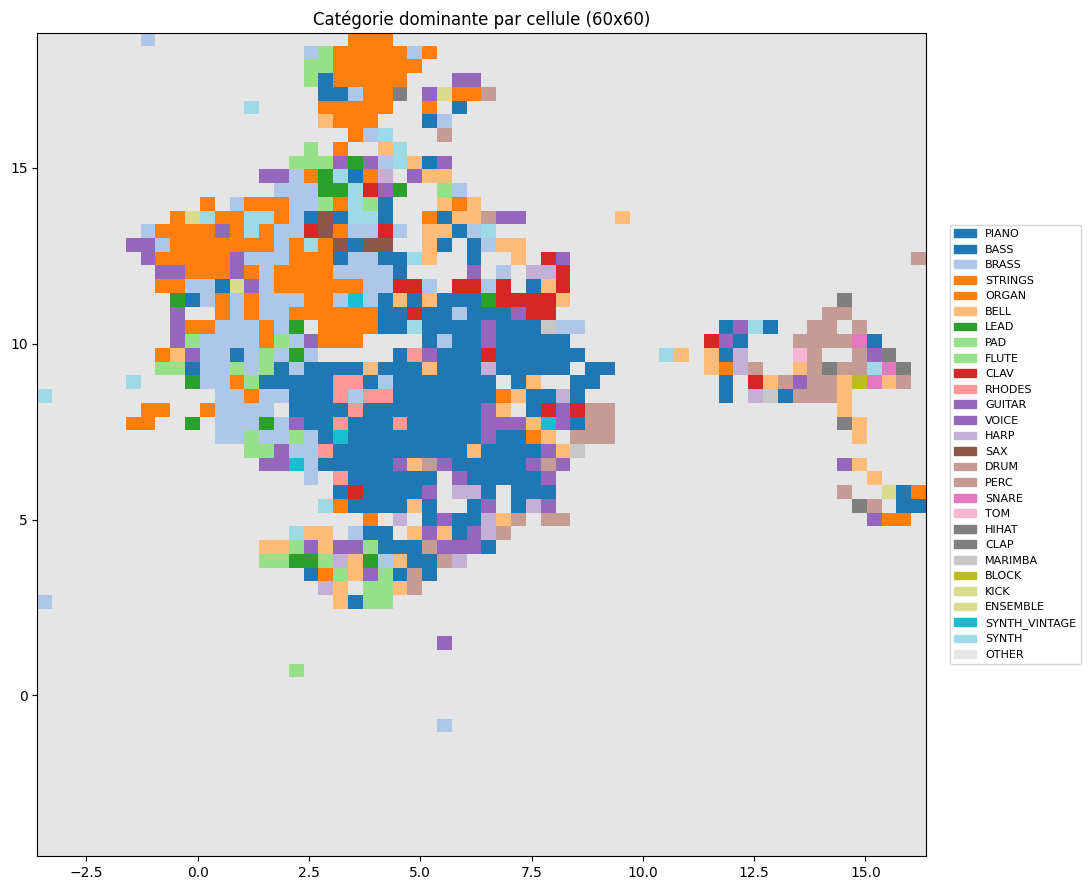

In [142]:
from scipy.stats import mode

n_bins = 60  # grille plus fine (60x60 au lieu de 30x30)
x_edges = np.linspace(X38u[:,0].min(), X38u[:,0].max(), n_bins+1)
y_edges = np.linspace(X38u[:,1].min(), X38u[:,1].max(), n_bins+1)

grid_cat = np.full((n_bins, n_bins), 'OTHER', dtype=object)
cat_array = cat_labels.reindex(behaviour_df.index).values

for i in range(n_bins):
    for j in range(n_bins):
        in_cell = (X38u[:,0] >= x_edges[i]) & (X38u[:,0] < x_edges[i+1]) & \
                  (X38u[:,1] >= y_edges[j]) & (X38u[:,1] < y_edges[j+1])
        cats_in_cell = cat_array[in_cell]
        cats_in_cell = cats_in_cell[cats_in_cell != 'OTHER']
        if len(cats_in_cell) >= 2:  # seuil abaissé, grille plus fine = moins de points par cellule
            vals, counts = np.unique(cats_in_cell, return_counts=True)
            grid_cat[i, j] = vals[np.argmax(counts)]

all_cats_ordered = list(categories.keys()) + ['OTHER']
cat_to_int = {c: i for i, c in enumerate(all_cats_ordered)}
grid_int = np.vectorize(cat_to_int.get)(grid_cat)

# Colormap discrète avec une couleur par catégorie
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap_colors = plt.cm.tab20(np.linspace(0, 1, len(all_cats_ordered)))
cmap_colors[all_cats_ordered.index('OTHER')] = [0.9, 0.9, 0.9, 1.0]  # gris clair pour OTHER
cmap = ListedColormap(cmap_colors)
norm = BoundaryNorm(np.arange(len(all_cats_ordered)+1)-0.5, cmap.N)

fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(grid_int.T, origin='lower', cmap=cmap, norm=norm,
               extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], aspect='auto')
ax.set_title(f'Catégorie dominante par cellule ({n_bins}x{n_bins})')

# Légende avec patches colorés
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap_colors[i], label=cat) for i, cat in enumerate(all_cats_ordered)]
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.tight_layout(); plt.show()

### 6.7 Density contours per category

In [143]:
import plotly.graph_objects as go
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import soundfile as sf
import matplotlib.colors as mcolors

audio_output = widgets.Output()

uids_list = list(behaviour_df.index)
names_list = [db.get_preset_name(uid) for uid in uids_list]
cat_array = cat_labels.reindex(behaviour_df.index).values

all_options = list(categories.keys()) + ['OTHER']

# Palette large pour couvrir 27 catégories + OTHER
qualitative_colors = (list(mcolors.TABLEAU_COLORS.values())
                      + list(plt.cm.Set1(np.linspace(0,1,9)))
                      + list(plt.cm.Set3(np.linspace(0,1,12)))
                      + list(plt.cm.Pastel1(np.linspace(0,1,9))))
colors_hex = [mcolors.to_hex(c) for c in qualitative_colors[:len(categories)]]
colors_hex.append('#d4d4d4')  # gris pour OTHER
zone_to_color = dict(zip(all_options, colors_hex))

# Widget de sélection : les catégories les plus peuplées cochées par défaut
default_selection = [c for c in categories.keys()
                      if (cat_labels == c).sum() >= 300]  # seuil pour ne pas surcharger au premier affichage

selector = widgets.SelectMultiple(
    options=all_options,
    value=tuple(default_selection),
    description='Catégories :',
    layout=widgets.Layout(width='220px', height='500px')
)

fig = go.FigureWidget(
    data=[go.Scatter(x=[], y=[], mode='markers', marker=dict(size=5, color=[]), text=[], hoverinfo='text')],
    layout=go.Layout(width=850, height=800, title="Sélectionne les catégories (Ctrl/Cmd+clic pour plusieurs)")
)

def update_plot(*args):
    selected = set(selector.value)
    mask = np.isin(cat_array, list(selected))
    with fig.batch_update():
        fig.data[0].x = X38u[mask, 0]
        fig.data[0].y = X38u[mask, 1]
        fig.data[0].marker.color = [zone_to_color[z] for z in cat_array[mask]]
        fig.data[0].text = [f"UID {uids_list[i]}: {names_list[i]} [{cat_array[i]}]"
                             for i in np.where(mask)[0]]

selector.observe(update_plot, names='value')
update_plot()

def on_click(trace, points, state):
    if points.point_inds:
        idx = points.point_inds[0]
        x_click, y_click = trace.x[idx], trace.y[idx]
        full_idx = np.where((X38u[:,0]==x_click) & (X38u[:,1]==y_click))[0][0]
        uid = uids_list[full_idx]
        name = names_list[full_idx]
        path = wav_path(uid, 0)
        with audio_output:
            clear_output(wait=True)
            print(f"UID {uid} - {name} [{cat_array[full_idx]}]")
            audio, sr = sf.read(path)
            display(Audio(audio, rate=sr))

fig.data[0].on_click(on_click)

display(widgets.HBox([selector, fig]))
display(audio_output)

Output()

### 6.8 PCA coloured by category

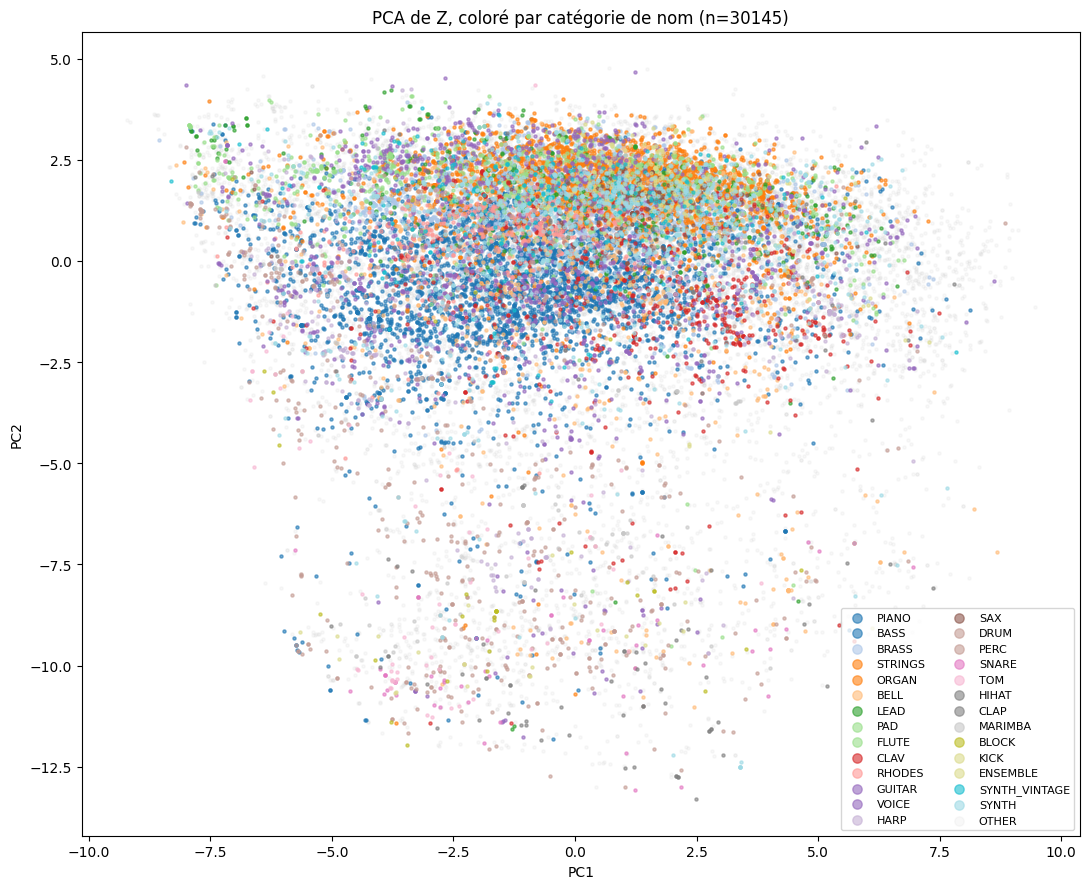

In [144]:
fig, ax = plt.subplots(figsize=(11,9))
palette = plt.cm.tab20(np.linspace(0, 1, len(categories)+1))
for i, cat in enumerate(list(categories.keys()) + ['OTHER']):
    mask = (cat_labels.reindex(behaviour_df.index) == cat).values
    color = 'lightgray' if cat == 'OTHER' else palette[i]
    zorder = 1 if cat == 'OTHER' else 2
    alpha = 0.15 if cat == 'OTHER' else 0.6
    ax.scatter(X38p[mask,0], X38p[mask,1], s=5, alpha=alpha, color=color, label=cat, zorder=zorder)
ax.legend(markerscale=3, loc='best', fontsize=8, ncol=2)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'PCA de Z, coloré par catégorie de nom (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

## 7. Categorisation by k-NN (label propagation for unclassified presets)

Precision k-NN : 64.2%
Categories finales: 27
Contient OTHER ? False
PIANO            3929
BASS             3443
STRINGS          3426
BRASS            3259
SYNTH            2069
BELL             1612
GUITAR           1583
ORGAN            1490
FLUTE            1208
CLAV             1110
VOICE            1084
LEAD              671
PERC              671
DRUM              636
RHODES            630
HARP              587
SYNTH_VINTAGE     556
ENSEMBLE          504
PAD               459
SAX               279
HIHAT             265
MARIMBA           194
TOM               147
SNARE             115
CLAP              112
BLOCK              71
KICK               35
dtype: int64

--- Repartition finale (noms reels + predictions k-NN) ---
PIANO           n= 3929
BASS            n= 3443
STRINGS         n= 3426
BRASS           n= 3259
SYNTH           n= 2069
BELL            n= 1612
GUITAR          n= 1583
ORGAN           n= 1490
FLUTE           n= 1208
CLAV            n= 1110
VOICE           n= 1084


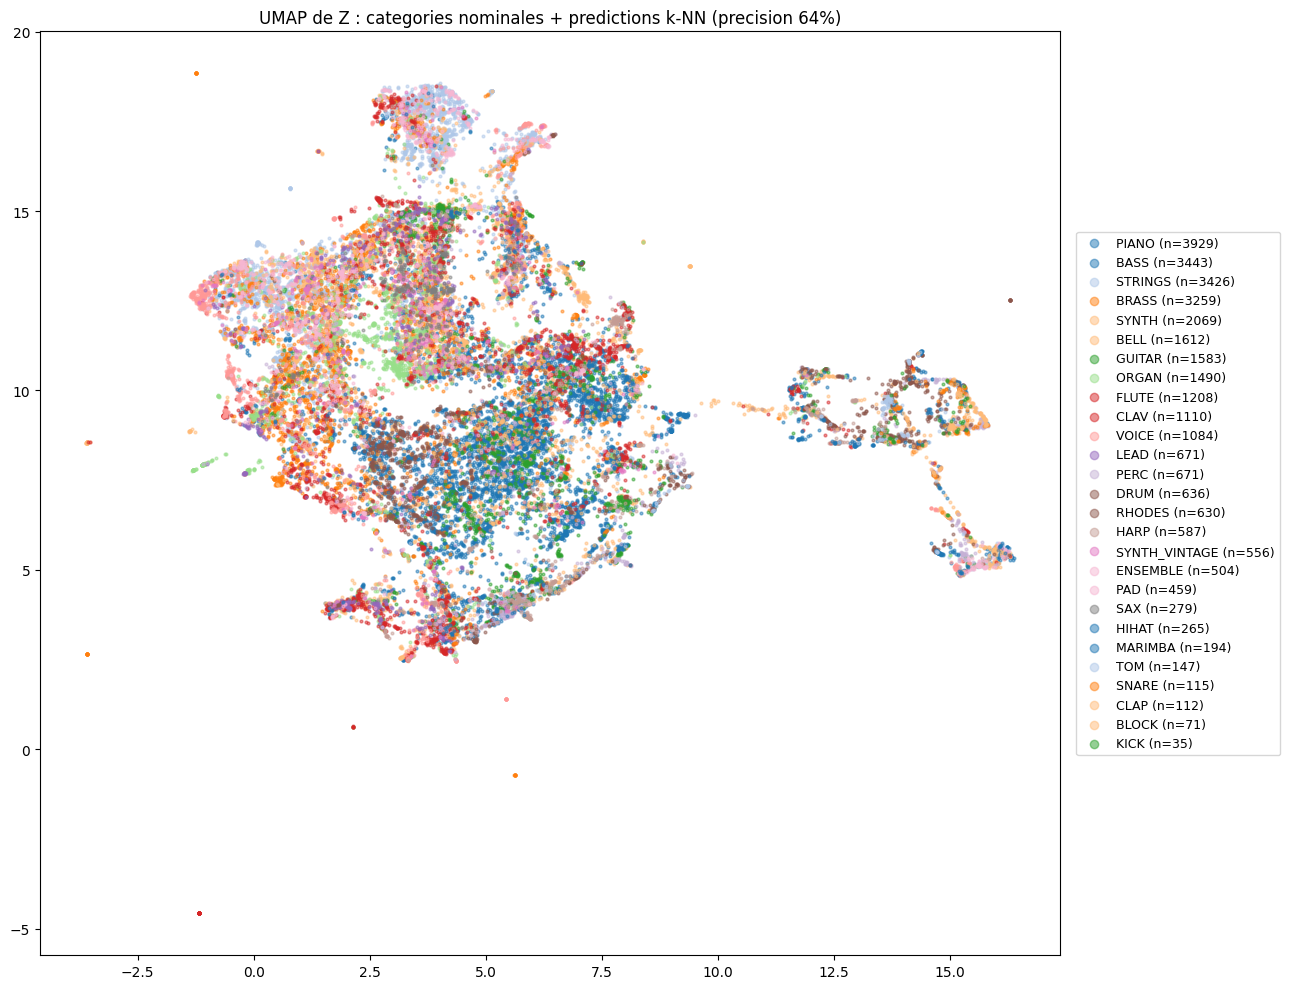

In [145]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Reconstruire proprement depuis cat_array (qui contient le vrai nom ou 'OTHER')
mask_labeled = cat_array != 'OTHER'
X_labeled = X38[mask_labeled]
y_labeled = cat_array[mask_labeled]

knn_val = KNeighborsClassifier(n_neighbors=5, weights='distance')
scores = cross_val_score(knn_val, X_labeled, y_labeled, cv=5)
print(f"Precision k-NN : {scores.mean()*100:.1f}%")

knn_final = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_final.fit(X_labeled, y_labeled)

mask_other = cat_array == 'OTHER'
predicted_labels = knn_final.predict(X38[mask_other])

point_zone_display = cat_array.copy()
point_zone_display[mask_other] = predicted_labels

print("Categories finales:", len(np.unique(point_zone_display)))
print("Contient OTHER ?", 'OTHER' in point_zone_display)
print(pd.Series(point_zone_display).value_counts())

print("\n--- Repartition finale (noms reels + predictions k-NN) ---")
zone_sizes = pd.Series(point_zone_display).value_counts().to_dict()
for zone, size in sorted(zone_sizes.items(), key=lambda x: -x[1]):
    print(f"{zone:15s} n={size:5d}")

# 4. Visualisation : meme structure que precedemment, avec les zones desormais completes
min_zone_size = 30  # seuil abaisse : plus besoin d'exclure grand-chose, le k-NN couvre tout
big_zones = [z for z, s in zone_sizes.items() if s >= min_zone_size]

fig, ax = plt.subplots(figsize=(13,10))
palette_zones = plt.cm.tab20(np.linspace(0, 1, len(big_zones)))

for i, zone in enumerate(big_zones):
    mask = point_zone_display == zone
    ax.scatter(X38u[mask,0], X38u[mask,1], s=4, alpha=0.5, color=palette_zones[i % 20],
               label=f"{zone} (n={mask.sum()})", zorder=2)

ax.legend(markerscale=3, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
ax.set_title(f'UMAP de Z : categories nominales + predictions k-NN (precision {scores.mean()*100:.0f}%)')
plt.tight_layout(); plt.show()

In [146]:
from sklearn.model_selection import train_test_split

# Simuler : on cache artificiellement 20% des noms connus, on prédit, on compare au vrai nom
X_train, X_test, y_train, y_test = train_test_split(X_labeled, y_labeled, test_size=0.2, random_state=0, stratify=y_labeled)

knn_test = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_test.fit(X_train, y_train)
y_pred = knn_test.predict(X_test)

agreement = (y_pred == y_test).sum()
print(f"Presets testes (20% caches artificiellement) : {len(y_test)}")
print(f"Accord (nom reel = prediction k-NN) : {agreement} ({100*agreement/len(y_test):.1f}%)")
print(f"Desaccord : {len(y_test)-agreement} ({100*(len(y_test)-agreement)/len(y_test):.1f}%)")

# Exemples concrets de désaccord
disagree_idx = np.where(y_pred != y_test)[0][:20]
print("\n--- Exemples de désaccord (nom réel vs prédiction k-NN) ---")
for i in disagree_idx:
    print(f"nom_reel={y_test[i]:10s}  prediction_kNN={y_pred[i]}")
    

Presets testes (20% caches artificiellement) : 3130
Accord (nom reel = prediction k-NN) : 2038 (65.1%)
Desaccord : 1092 (34.9%)

--- Exemples de désaccord (nom réel vs prédiction k-NN) ---
nom_reel=DRUM        prediction_kNN=PIANO
nom_reel=BASS        prediction_kNN=STRINGS
nom_reel=RHODES      prediction_kNN=SYNTH
nom_reel=BASS        prediction_kNN=ORGAN
nom_reel=PERC        prediction_kNN=TOM
nom_reel=TOM         prediction_kNN=MARIMBA
nom_reel=SYNTH       prediction_kNN=SYNTH_VINTAGE
nom_reel=SYNTH       prediction_kNN=BASS
nom_reel=BASS        prediction_kNN=ORGAN
nom_reel=PERC        prediction_kNN=DRUM
nom_reel=BELL        prediction_kNN=BRASS
nom_reel=GUITAR      prediction_kNN=PIANO
nom_reel=GUITAR      prediction_kNN=BELL
nom_reel=SYNTH_VINTAGE  prediction_kNN=BRASS
nom_reel=HARP        prediction_kNN=LEAD
nom_reel=SNARE       prediction_kNN=DRUM
nom_reel=ORGAN       prediction_kNN=FLUTE
nom_reel=CLAV        prediction_kNN=PIANO
nom_reel=CLAV        prediction_kNN=HARP
nom_re

In [147]:
import plotly.graph_objects as go
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import soundfile as sf
import matplotlib.colors as mcolors

audio_output = widgets.Output()

uids_list = list(behaviour_df.index)
names_list = [db.get_preset_name(uid) for uid in uids_list]

# point_zone_display vient maintenant du k-NN (categories.keys() + predictions), plus de notion d'OTHER residuel
all_options = sorted(pd.Series(point_zone_display).unique())

# Palette fixe (une couleur par catégorie)
qualitative_colors = (list(mcolors.TABLEAU_COLORS.values())
                      + list(plt.cm.Set1(np.linspace(0,1,9)))
                      + list(plt.cm.Set3(np.linspace(0,1,12))))
colors_hex = [mcolors.to_hex(c) for c in qualitative_colors[:len(all_options)]]
zone_to_color = dict(zip(all_options, colors_hex))

# Widget de sélection multiple des catégories à afficher (toutes cochées par défaut)
selector = widgets.SelectMultiple(
    options=all_options,
    value=tuple(all_options),
    description='Catégories :',
    layout=widgets.Layout(width='250px', height='500px')
)

fig = go.FigureWidget(
    data=[go.Scatter(x=[], y=[], mode='markers', marker=dict(size=5, color=[]), text=[], hoverinfo='text')],
    layout=go.Layout(width=850, height=800, title="Sélectionne les catégories à afficher (k-NN, precision ~64%)")
)

def update_plot(*args):
    selected = set(selector.value)
    mask = np.isin(point_zone_display, list(selected))
    with fig.batch_update():
        fig.data[0].x = X38u[mask, 0]
        fig.data[0].y = X38u[mask, 1]
        fig.data[0].marker.color = [zone_to_color[z] for z in point_zone_display[mask]]
        fig.data[0].text = [f"UID {uids_list[i]}: {names_list[i]} ({point_zone_display[i]})"
                             for i in np.where(mask)[0]]

selector.observe(update_plot, names='value')
update_plot()

def on_click(trace, points, state):
    if points.point_inds:
        idx = points.point_inds[0]
        x_click, y_click = trace.x[idx], trace.y[idx]
        full_idx = np.where((X38u[:,0]==x_click) & (X38u[:,1]==y_click))[0][0]
        uid = uids_list[full_idx]
        name = names_list[full_idx]
        path = wav_path(uid, 0)
        with audio_output:
            clear_output(wait=True)
            print(f"UID {uid} - {name} [{point_zone_display[full_idx]}]")
            audio, sr = sf.read(path)
            display(Audio(audio, rate=sr))

fig.data[0].on_click(on_click)

display(widgets.HBox([selector, fig]))
display(audio_output)

Output()

## 8. Semantic vs spectral descriptor comparison

`ac_brightness` is a semantic/perceptual descriptor. Colouring by a raw spectral TT feature
(`tt_SpecCent_IQR`, the interquartile range of spectral centroid over time -- a proxy for
how much the timbre's brightness varies within a single note) checks whether the map's
structure is specific to one descriptor or reflects a more general organisation.

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


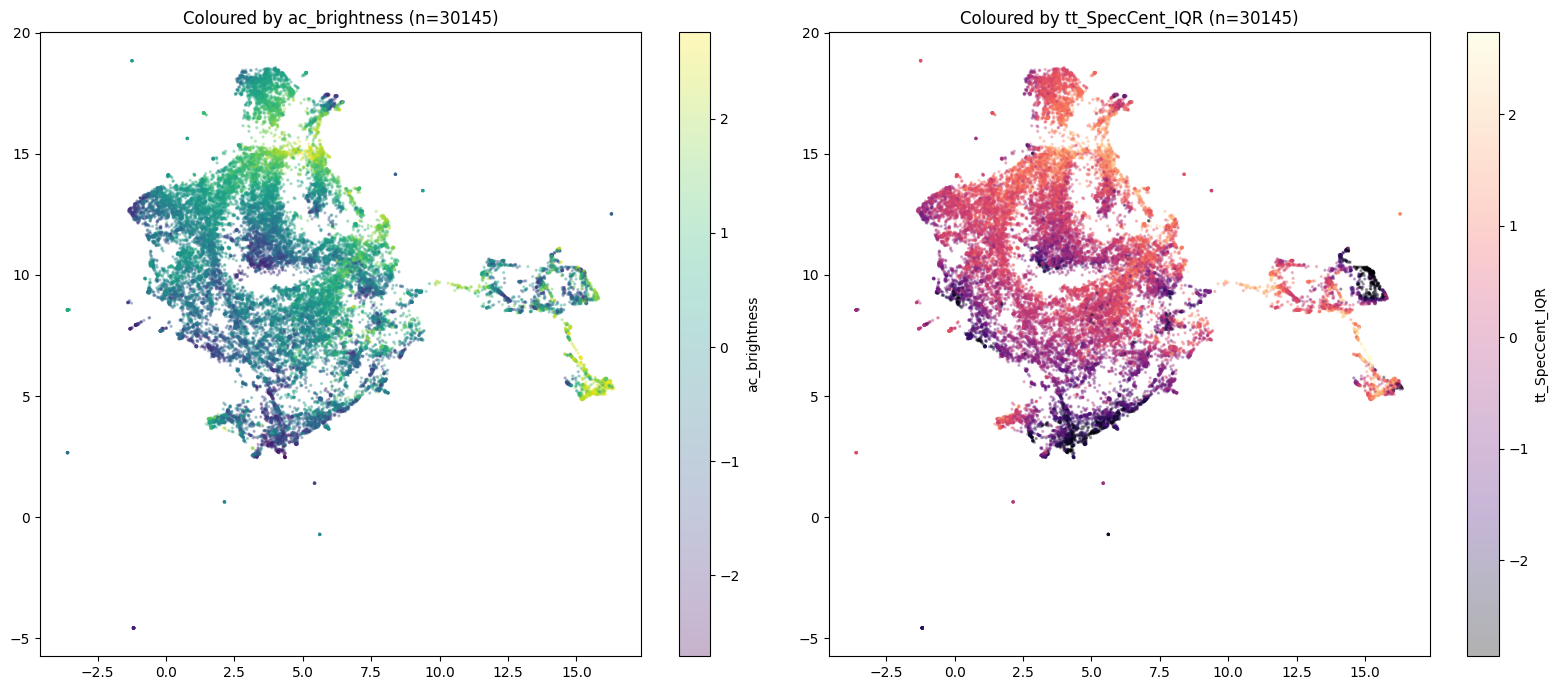

In [148]:
reducer38b = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
X38u_b = reducer38b.fit_transform(X38)  # same embedding params, kept separate for clarity

fig, axes = plt.subplots(1, 2, figsize=(16,7))
sc0 = axes[0].scatter(X38u_b[:,0], X38u_b[:,1], c=behaviour_df['ac_brightness'], s=2, cmap='viridis', alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label='ac_brightness')
axes[0].set_title(f'Coloured by ac_brightness (n={len(X38u_b)})')

sc1 = axes[1].scatter(X38u_b[:,0], X38u_b[:,1], c=behaviour_df['tt_SpecCent_IQR'], s=2, cmap='magma', alpha=0.3)
plt.colorbar(sc1, ax=axes[1], label='tt_SpecCent_IQR')
axes[1].set_title(f'Coloured by tt_SpecCent_IQR (n={len(X38u_b)})')
plt.tight_layout(); plt.show()

## 9. Quantifying UMAP coverage

Two simple, standard Quality-Diversity coverage metrics, computed on the UMAP embedding:
- **Grid occupancy**: divide the 2D map into an N x N grid, count occupied cells / total cells.
- **Mean nearest-neighbour distance**: average distance from each point to its closest neighbour
  -- higher values indicate sparser, more uneven coverage.

These give a numeric baseline to compare against once IMGEP-guided exploration is available.

In [149]:
from scipy.spatial import cKDTree

def grid_occupancy(points, n_bins=20):
    x, y = points[:,0], points[:,1]
    x_edges = np.linspace(x.min(), x.max(), n_bins+1)
    y_edges = np.linspace(y.min(), y.max(), n_bins+1)
    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    occupied = (H > 0).sum()
    total = n_bins * n_bins
    return occupied / total, occupied, total

def mean_nn_distance(points):
    tree = cKDTree(points)
    dists, _ = tree.query(points, k=2)  # k=1 is itself (dist 0), k=2 is the true nearest neighbour
    return float(np.mean(dists[:,1]))

occ_ratio, occ_cells, total_cells = grid_occupancy(X38u, n_bins=50)
nn_dist = mean_nn_distance(X38u)
print(f"Grid occupancy (50x50): {occ_cells}/{total_cells} cells = {100*occ_ratio:.1f}%")
print(f"Mean nearest-neighbour distance: {nn_dist:.4f}")
print(f"(sur {len(X38u)} presets)")

Grid occupancy (50x50): 671/2500 cells = 26.8%
Mean nearest-neighbour distance: 0.0228
(sur 30145 presets)


## 10. Coverage map in the raw parameter space (Θ)

Same PCA/UMAP/coverage analysis, but performed directly on the 155 raw Dexed parameters
instead of the 38-feature behaviour space. This checks whether human-made presets cover
the parameter space Θ as unevenly as they cover the perceptual behaviour space Z, and
whether the two spaces show a similar or markedly different structure -- which would
be informative about the non-linearity of the Θ→Z mapping that SpinVAE2 itself is
built to learn.

### 10.1 Raw parameters matrix

In [164]:
# Récupérer les paramètres bruts pour tous les presets (variation 0 = presets originaux)
from synth.dexed import PresetDfDatabase
db = PresetDfDatabase()

all_uids_ordered = list(behaviour_df.index)  # même ordre que le comportement, pour comparer
params_matrix = np.array([db.get_preset_params_values(uid) for uid in all_uids_ordered])
print("Shape params bruts:", params_matrix.shape)  # attendu: (30145, 155)

Shape params bruts: (30145, 155)


### 10.2 PCA

Explained variance Theta (2 PCs): 0.17467707


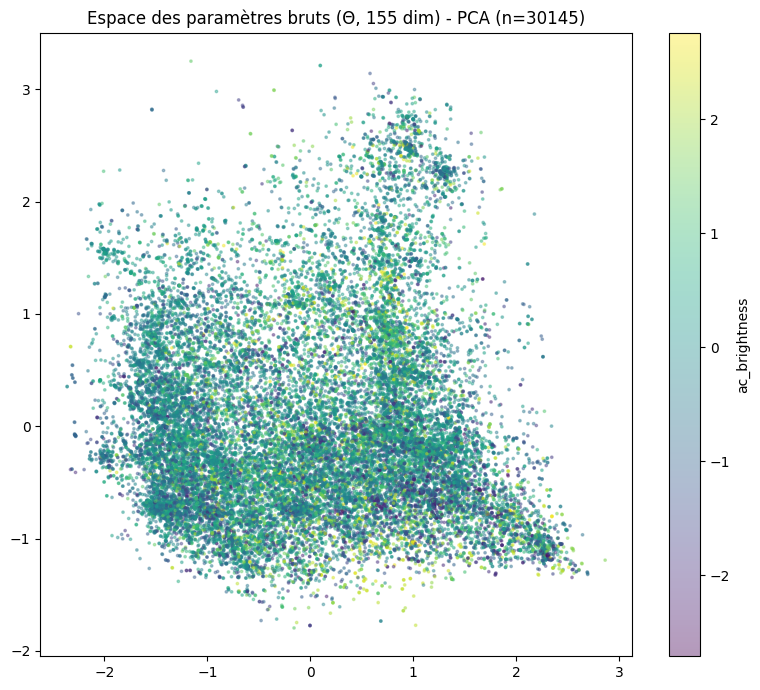

In [165]:
pca_theta = PCA(n_components=2)
Xtheta_p = pca_theta.fit_transform(params_matrix)
print('Explained variance Theta (2 PCs):', pca_theta.explained_variance_ratio_[:2].sum())

plot_2d(Xtheta_p, behaviour_df['ac_brightness'],
        f'Espace des paramètres bruts (Θ, 155 dim) - PCA (n={len(params_matrix)})',
        colorbar_label='ac_brightness', s=3, alpha=0.4, figsize=(8, 7))


### 10.3 UMAP

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


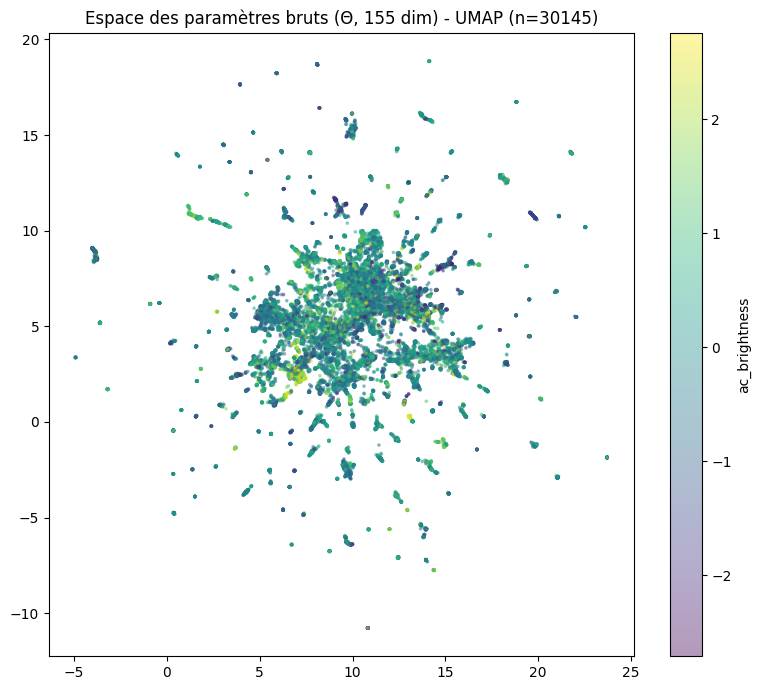

In [166]:
reducer_theta = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
Xtheta_u = reducer_theta.fit_transform(params_matrix)

plot_2d(Xtheta_u, behaviour_df['ac_brightness'],
        f'Espace des paramètres bruts (Θ, 155 dim) - UMAP (n={len(params_matrix)})',
        colorbar_label='ac_brightness', s=3, alpha=0.4, figsize=(8, 7))


### 10.4 Coverage metrics

In [167]:
occ_ratio_theta, occ_cells_theta, total_cells_theta = grid_occupancy(Xtheta_u, n_bins=50)
nn_dist_theta = mean_nn_distance(Xtheta_u)
print(f"Grid occupancy Theta (50x50): {occ_cells_theta}/{total_cells_theta} = {100*occ_ratio_theta:.1f}%")
print(f"Mean NN distance Theta: {nn_dist_theta:.4f}")

Grid occupancy Theta (50x50): 513/2500 = 20.5%
Mean NN distance Theta: 0.0141


## 11. Native 38D coverage metrics and alternative projections

Coverage metrics computed on 2D embeddings (PCA, UMAP) are limited by the fact that these
projections are not isometries -- distances and neighbourhoods can be distorted. Here we
compute nearest-neighbour-based coverage metrics directly in the native 38-dimensional
behaviour space, and compare against a uniform-random baseline of the same size and bounding
box. We also compare UMAP against t-SNE and Isomap as alternative 2D projections.

### 11.1 Native ND metrics vs uniform-random baseline

In [154]:
from scipy.spatial import cKDTree

def mean_nn_distance_nd(X):
    tree = cKDTree(X)
    dists, _ = tree.query(X, k=2)
    return float(np.mean(dists[:,1]))

def mean_knn_distance_nd(X, k=5):
    tree = cKDTree(X)
    dists, _ = tree.query(X, k=k+1)
    return float(np.mean(dists[:,1:]))

nn_dist_38d = mean_nn_distance_nd(X38)
knn5_38d = mean_knn_distance_nd(X38, k=5)
print(f"Mean NN distance (native 38D): {nn_dist_38d:.4f}")
print(f"Mean 5-NN distance (native 38D): {knn5_38d:.4f}")

# Baseline: uniform random sample, same size and bounding box
np.random.seed(0)
X_uniform_random = np.random.uniform(X38.min(axis=0), X38.max(axis=0), size=X38.shape)
nn_dist_random = mean_nn_distance_nd(X_uniform_random)
knn5_random = mean_knn_distance_nd(X_uniform_random, k=5)

print(f"\nMean NN distance (uniform random baseline): {nn_dist_random:.4f}")
print(f"Mean 5-NN distance (uniform random baseline): {knn5_random:.4f}")

print(f"\nRatio NN (dataset / uniform random): {nn_dist_38d / nn_dist_random:.3f}")
print(f"Ratio 5-NN (dataset / uniform random): {knn5_38d / knn5_random:.3f}")

Mean NN distance (native 38D): 1.1234
Mean 5-NN distance (native 38D): 1.8008

Mean NN distance (uniform random baseline): 9.7055
Mean 5-NN distance (uniform random baseline): 10.2104

Ratio NN (dataset / uniform random): 0.116
Ratio 5-NN (dataset / uniform random): 0.176


### 11.2 t-SNE / Isomap on a subsample

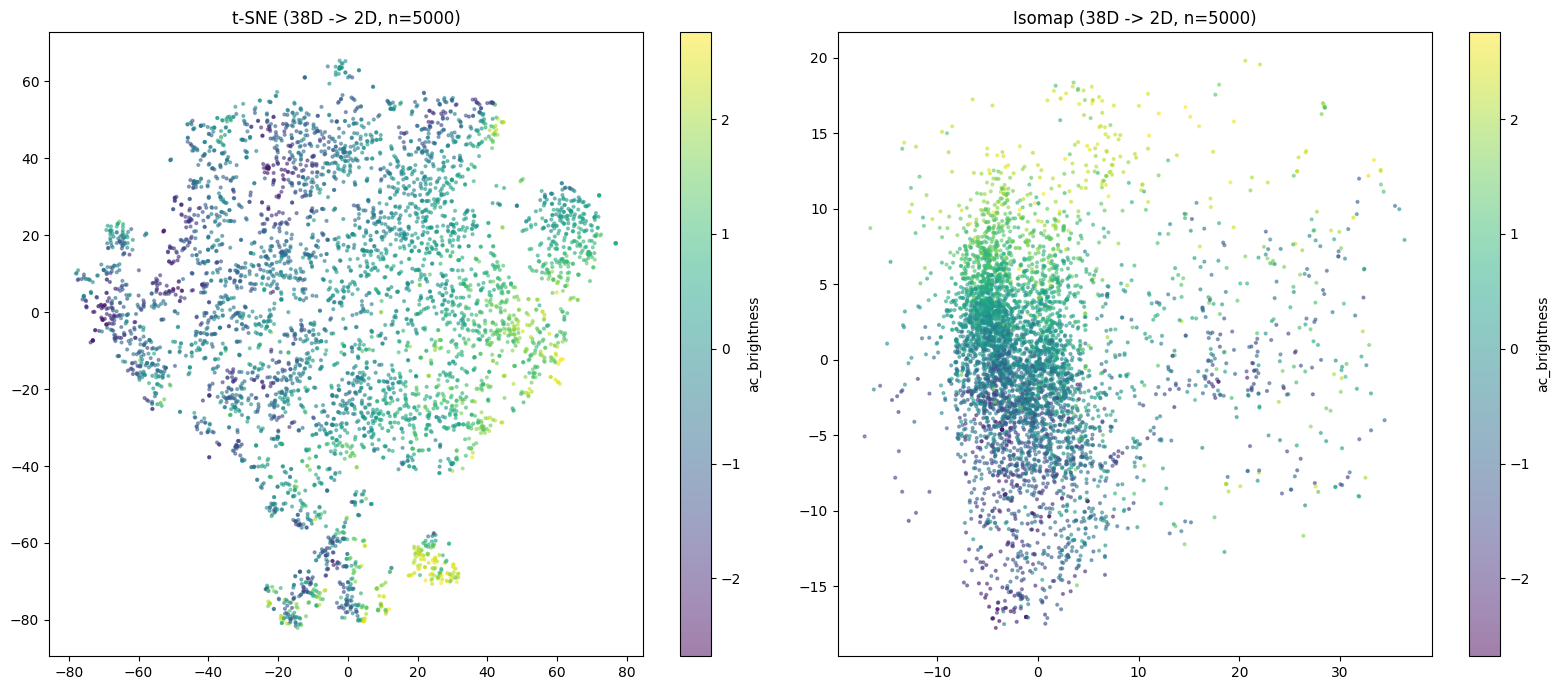

In [155]:
from sklearn.manifold import TSNE, Isomap

# Sous-échantillon pour garder ça rapide (t-SNE/Isomap sont coûteux sur 30k points)
n_sub = 5000
np.random.seed(0)
sub_idx = np.random.choice(len(X38), size=n_sub, replace=False)
X38_sub = X38[sub_idx]
brightness_sub = behaviour_df['ac_brightness'].values[sub_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
X38_tsne = tsne.fit_transform(X38_sub)

isomap = Isomap(n_components=2, n_neighbors=15)
X38_isomap = isomap.fit_transform(X38_sub)

fig, axes = plt.subplots(1, 2, figsize=(16,7))
sc0 = axes[0].scatter(X38_tsne[:,0], X38_tsne[:,1], c=brightness_sub, s=4, cmap='viridis', alpha=0.5)
axes[0].set_title(f't-SNE (38D -> 2D, n={n_sub})')
plt.colorbar(sc0, ax=axes[0], label='ac_brightness')

sc1 = axes[1].scatter(X38_isomap[:,0], X38_isomap[:,1], c=brightness_sub, s=4, cmap='viridis', alpha=0.5)
axes[1].set_title(f'Isomap (38D -> 2D, n={n_sub})')
plt.colorbar(sc1, ax=axes[1], label='ac_brightness')
plt.tight_layout(); plt.show()

### 11.3 t-SNE on the full dataset

t-SNE (30k) termine en 319.3s


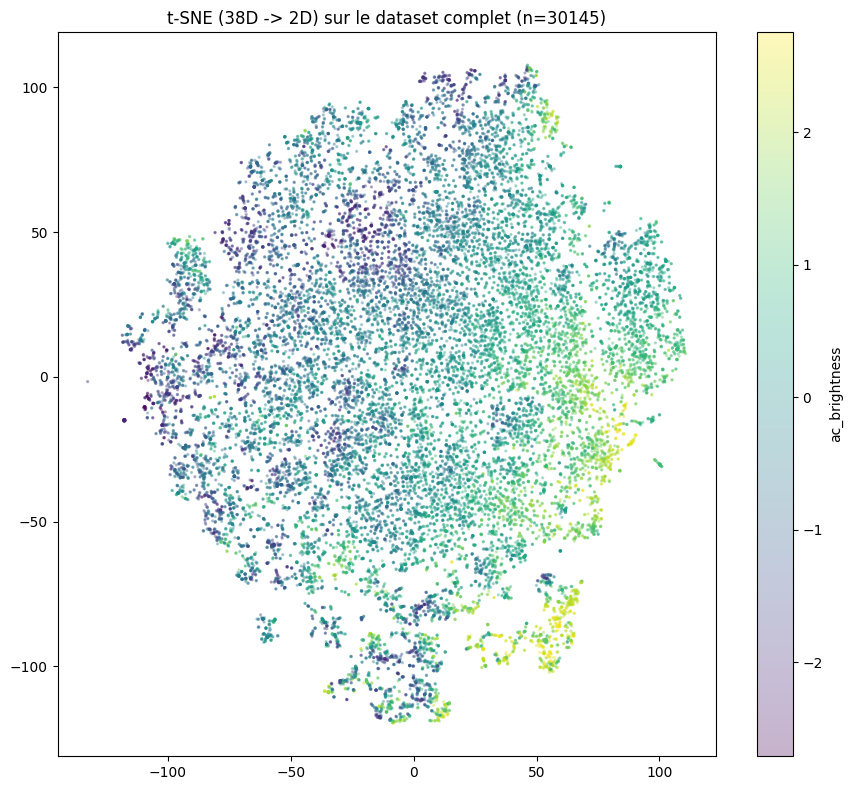

In [156]:
import time
from sklearn.manifold import TSNE

t0 = time.time()
tsne_full = TSNE(n_components=2, perplexity=30, random_state=0, n_jobs=-1)
X38_tsne_full = tsne_full.fit_transform(X38)
print(f"t-SNE (30k) termine en {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(9,8))
sc = ax.scatter(X38_tsne_full[:,0], X38_tsne_full[:,1], c=behaviour_df['ac_brightness'], s=2, cmap='viridis', alpha=0.3)
plt.colorbar(sc, label='ac_brightness')
ax.set_title(f't-SNE (38D -> 2D) sur le dataset complet (n={len(X38_tsne_full)})')
plt.tight_layout(); plt.show()

### 11.4 t-SNE coloured by category

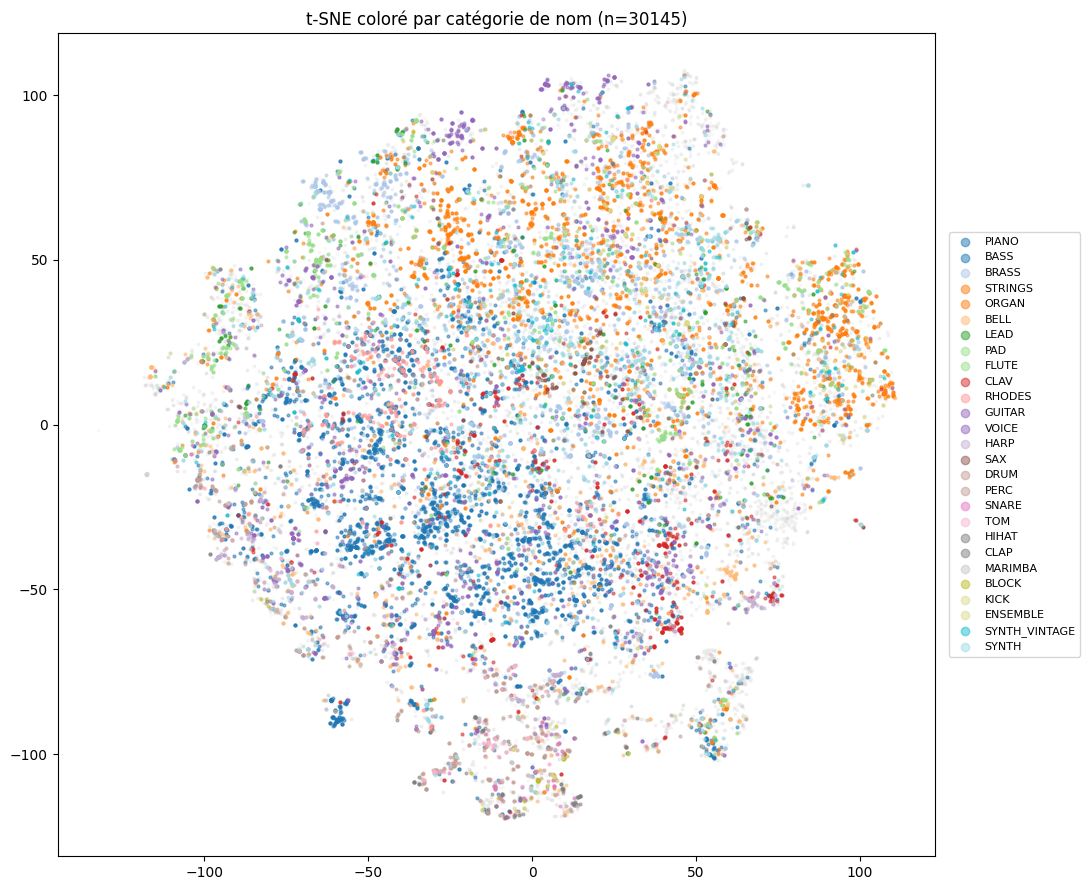

In [157]:
fig, ax = plt.subplots(figsize=(11,9))
palette = plt.cm.tab20(np.linspace(0, 1, len(categories)+1))
cat_array = cat_labels.reindex(behaviour_df.index).values

mask_other = cat_array == 'OTHER'
ax.scatter(X38_tsne_full[mask_other,0], X38_tsne_full[mask_other,1], s=3, alpha=0.1, color='lightgray', zorder=1)

for i, cat in enumerate(categories.keys()):
    mask = cat_array == cat
    ax.scatter(X38_tsne_full[mask,0], X38_tsne_full[mask,1], s=4, alpha=0.5, color=palette[i], label=cat, zorder=2)

ax.legend(markerscale=3, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.set_title(f't-SNE coloré par catégorie de nom (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

## 12. Summary of results so far

- The canonical 38-feature behaviour space (6 ACTM + 32 TT, exactly matching the SpinVAE2 paper's
  selection) was successfully reproduced from the regenerated Dexed dataset.
- PCA on this space explains ~44% of variance on 2 components -- the space is genuinely
  multi-dimensional, no single pair of axes summarises it well.
- The UMAP projection shows a broadly connected structure, but with visibly denser and sparser
  sub-regions, and at least one small, distinctly separated cluster of bright/high-`ac_brightness`
  presets, isolated from the main body of points.
- Colouring by a purely spectral TT feature (`tt_SpecCent_IQR`) shows a similar (though not
  identical) organisation to the semantic ACTM feature, suggesting the map's structure is not an
  artefact of one specific descriptor.
- Grid occupancy and nearest-neighbour distance give a first quantitative coverage baseline,
  computed on 500 presets so far -- to be recomputed on the full 30k-preset dataset once the
  ongoing TT+ACTM computation on `bonsho` finishes.

## 13. Export presets for local listening

Pick UIDs of interest (e.g. sparse regions of the canonical map) and copy their wav files, then from your
local machine: `scp 'bonsho:~/to_download/*.wav' ~/dexed_listen/`

In [158]:
import shutil
DL_DIR = os.path.expanduser('~/to_download')
os.makedirs(DL_DIR, exist_ok=True)

def export_for_download(uids, variation=0):
    copied = []
    for uid in uids:
        src = wav_path(uid, variation)
        if os.path.exists(src):
            name = db.get_preset_name(uid).replace('/', '_').replace(' ', '_')
            dst = os.path.join(DL_DIR, f"{uid:06d}_{name}.wav")
            shutil.copy(src, dst)
            copied.append(dst)
    print(f"Copied {len(copied)} files to {DL_DIR}")
    return copied

example_uids = list(behaviour_df.sample(min(10, len(behaviour_df)), random_state=1).index)
export_for_download(example_uids)

Copied 10 files to /u/anasynth/longeot/to_download


['/u/anasynth/longeot/to_download/002815_AN.STRG_1B.wav',
 '/u/anasynth/longeot/to_download/141300_PIANOBELL2.wav',
 '/u/anasynth/longeot/to_download/002188__KALIMBA__.wav',
 '/u/anasynth/longeot/to_download/029905_Hand_Claps.wav',
 '/u/anasynth/longeot/to_download/008242_BRASS__14_.wav',
 '/u/anasynth/longeot/to_download/245571_Brass_2___.wav',
 '/u/anasynth/longeot/to_download/007544_WILD_BOAR_.wav',
 '/u/anasynth/longeot/to_download/112662_JX-10___2_.wav',
 '/u/anasynth/longeot/to_download/075368_Xylophone4.wav',
 '/u/anasynth/longeot/to_download/004194____OBOE___.wav']

## 14. Investigating the detached UMAP cluster

### 14.1 Robust outlier/cluster detection (HDBSCAN, native 38D)

The previous version hard-coded UMAP-embedding bounds (`X38u[:,0] > 12 ...`) to isolate the
detached cluster -- fragile, since those bounds depend on the specific UMAP run (`random_state`,
data version) and are meaningless if either changes. HDBSCAN run directly on the native 38D
behaviour space `X38` gives a reproducible, embedding-independent detection instead.

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Nombre de clusters trouves: 2
Points classes comme outliers (-1): 2691

Taille des clusters HDBSCAN:
-1     2691
 0      398
 1    27056
dtype: int64


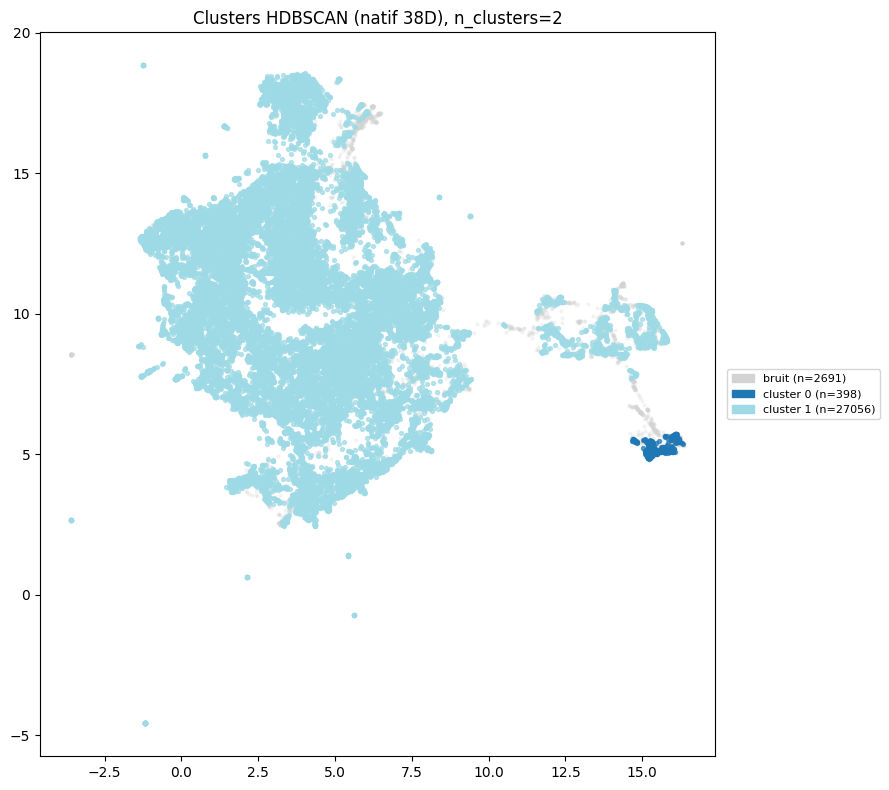


--- Clusters tries par distance au centre global (candidats 'detaches') ---
cluster      n  dist_centre  rayon_interne
      0    398        11.79           0.45
      1  27056         0.57           4.15  <- filament clairseme, a verifier

Cluster retenu: 0 (n=398)


In [172]:
import hdbscan
import matplotlib.patches as mpatches

# Detection d'outliers/clusters directement dans l'espace natif 38D (pas sur l'embedding 2D).
# min_cluster_size releve (150 au lieu de 50) + cluster_selection_epsilon pour eviter de
# fragmenter un filament clairseme (queue de distribution) en plusieurs petits clusters
# arbitraires -- cf. 14.1 precedent, ou le "bras detache" etait decoupe en 3 sous-clusters
# + bruit sans separation reelle entre eux.
clusterer = hdbscan.HDBSCAN(min_cluster_size=150, min_samples=15, cluster_selection_epsilon=0.5)
hdbscan_labels = clusterer.fit_predict(X38)

n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
print("Nombre de clusters trouves:", n_clusters_hdbscan)
print("Points classes comme outliers (-1):", (hdbscan_labels == -1).sum())
print("\nTaille des clusters HDBSCAN:")
print(pd.Series(hdbscan_labels).value_counts().sort_index())

# Affichage a couleurs discretes + legende explicite (le -1/bruit et les petits clusters
# etaient auparavant illisibles avec une colormap continue 'tab20' etiree sur les labels)
cluster_ids_sorted = sorted(set(hdbscan_labels))
palette_hdbscan = plt.cm.tab20(np.linspace(0, 1, max(len(cluster_ids_sorted) - 1, 1)))
fig, ax = plt.subplots(figsize=(9, 8))
legend_patches = []
color_idx = 0
for cid in cluster_ids_sorted:
    mask = hdbscan_labels == cid
    if cid == -1:
        color, alpha, size, zorder = 'lightgray', 0.2, 4, 1
        label = f'bruit (n={mask.sum()})'
    else:
        color, alpha, size, zorder = palette_hdbscan[color_idx], 0.7, 8, 2
        color_idx += 1
        label = f'cluster {cid} (n={mask.sum()})'
    ax.scatter(X38u[mask, 0], X38u[mask, 1], s=size, alpha=alpha, color=color, zorder=zorder)
    legend_patches.append(mpatches.Patch(color=color, label=label))
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.set_title(f'Clusters HDBSCAN (natif 38D), n_clusters={n_clusters_hdbscan}')
plt.tight_layout(); plt.show()

# Classement des clusters (hors bruit) par distance au centre global, + un indicateur de
# compacite (rayon moyen au centre du cluster) : un "vrai" cluster detache doit etre a la
# fois loin du centre global ET compact -- un filament clairseme aura un rayon interne
# elevé, signe qu'il ne s'agit pas d'un groupe timbral homogene mais d'une queue de
# distribution artificiellement decoupee.
detached_candidates = []
for c in cluster_ids_sorted:
    if c == -1:
        continue
    mask = hdbscan_labels == c
    center_2d = X38u[mask].mean(axis=0)
    dist_from_global_center = np.linalg.norm(center_2d - X38u.mean(axis=0))
    internal_radius = np.linalg.norm(X38u[mask] - center_2d, axis=1).mean()
    detached_candidates.append((c, mask.sum(), dist_from_global_center, internal_radius))

detached_candidates.sort(key=lambda x: -x[2])
print("\n--- Clusters tries par distance au centre global (candidats 'detaches') ---")
print(f"{'cluster':>7s} {'n':>6s} {'dist_centre':>12s} {'rayon_interne':>14s}")
for c, size, dist, radius in detached_candidates[:5]:
    flag = '  <- filament clairseme, a verifier' if radius > dist * 0.5 else ''
    print(f"{c:7d} {size:6d} {dist:12.2f} {radius:14.2f}{flag}")

detached_cluster_id = detached_candidates[0][0]
mask_detached = hdbscan_labels == detached_cluster_id
print(f"\nCluster retenu: {detached_cluster_id} (n={mask_detached.sum()})")


### 14.2 Sub-clustering the main cluster

The big cluster found above (n≈27k) is itself almost certainly not homogeneous -- it is
just "everything dense enough not to be noise or a separate arm". A first attempt re-ran
HDBSCAN with a smaller `min_cluster_size` restricted to this cluster, but 72% of points
(19532/27056) ended up as noise: the main body is a dense, roughly continuous blob with no
real empty gaps inside it, which is exactly the case HDBSCAN struggles with -- it is built to
find islands separated by low-density regions, not to partition a continuum.

K-means is used instead: it partitions every point (no leftover "noise" bucket), which fits
a continuum better, at the cost of assuming roughly convex, comparably-sized clusters (a
reasonable approximation here, to be checked against the resulting audio/word labels).

Cluster principal: id=1, n=27056
K-means (k=12) sur le corps principal

Taille des sous-clusters:
0      326
1     2035
2     2190
3      605
4      329
5     3834
6     5355
7     3887
8     2678
9     1511
10    2140
11    2166
dtype: int64


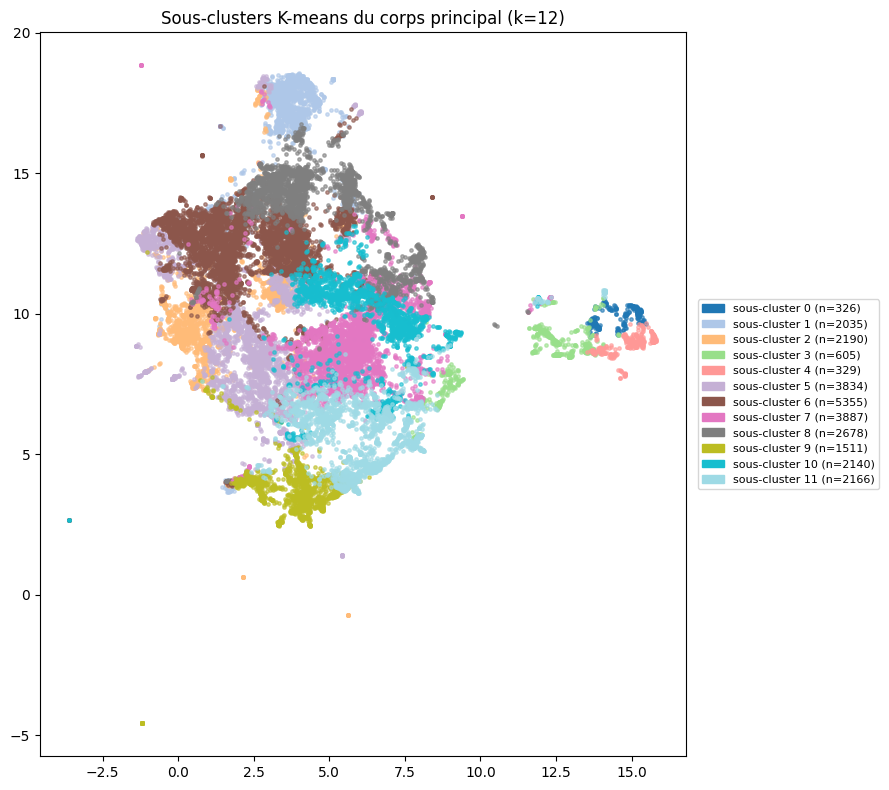


--- Mots dominants par sous-cluster ---
Sous-cluster  0 (n=  326): [('DRUM', 22), ('E', 10), ('SIMMONS', 10), ('TOM', 10), ('TOMS', 10)]
Sous-cluster  1 (n= 2035): [('STRINGS', 159), ('STRING', 82), ('PAD', 70), ('STRG', 66), ('STR', 56)]
Sous-cluster  2 (n= 2190): [('ORGAN', 114), ('B', 84), ('BRASS', 82), ('HORN', 70), ('BASS', 70)]
Sous-cluster  3 (n=  605): [('HARP', 34), ('TIMPANI', 24), ('MARIMBA', 23), ('DRUM', 17), ('BASS', 17)]
Sous-cluster  4 (n=  329): [('SNR', 12), ('PERC', 12), ('DRUM', 10), ('CLAP', 10), ('BLOCK', 9)]
Sous-cluster  5 (n= 3834): [('PIANO', 254), ('E', 236), ('RHODES', 135), ('B', 132), ('BRASS', 96)]
Sous-cluster  6 (n= 5355): [('BRASS', 178), ('B', 151), ('A', 121), ('STRINGS', 120), ('Y', 115)]
Sous-cluster  7 (n= 3887): [('PIANO', 483), ('A', 106), ('E', 101), ('BASS', 95), ('CLAV', 87)]
Sous-cluster  8 (n= 2678): [('CLAV', 81), ('A', 66), ('BRASS', 57), ('E', 55), ('B', 51)]
Sous-cluster  9 (n= 1511): [('BASS', 51), ('A', 51), ('FLUTE', 47), ('PIANO',

In [40]:
# Isoler le plus gros cluster HDBSCAN (le "corps principal", cf. 14.1) avant de le sous-partitionner
main_cluster_id = max(
    (cid for cid in set(hdbscan_labels) if cid != -1),
    key=lambda cid: (hdbscan_labels == cid).sum()
)
mask_main = hdbscan_labels == main_cluster_id
X38_main = X38[mask_main]
X38u_main = X38u[mask_main]

from sklearn.cluster import KMeans

# Partition du corps principal par K-means (natif 38D) -- contrairement a HDBSCAN, tous les
# points sont assignes a un cluster, ce qui convient mieux a un blob dense et continu.
n_sub_clusters = 12
kmeans_main = KMeans(n_clusters=n_sub_clusters, random_state=0, n_init=10)
sub_labels = kmeans_main.fit_predict(X38_main)

print(f"Cluster principal: id={main_cluster_id}, n={mask_main.sum()}")
print(f"K-means (k={n_sub_clusters}) sur le corps principal")
print("\nTaille des sous-clusters:")
print(pd.Series(sub_labels).value_counts().sort_index())

palette_sub = plt.cm.tab20(np.linspace(0, 1, n_sub_clusters))
fig, ax = plt.subplots(figsize=(9, 8))
legend_patches = []
for sid in range(n_sub_clusters):
    mask = sub_labels == sid
    color = palette_sub[sid]
    ax.scatter(X38u_main[mask, 0], X38u_main[mask, 1], s=6, alpha=0.6, color=color, zorder=2)
    legend_patches.append(mpatches.Patch(color=color, label=f'sous-cluster {sid} (n={mask.sum()})'))
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.set_title(f'Sous-clusters K-means du corps principal (k={n_sub_clusters})')
plt.tight_layout(); plt.show()

# Mots dominants par sous-cluster, pour une premiere lecture qualitative
print("\n--- Mots dominants par sous-cluster ---")
main_uids = behaviour_df.index[mask_main]
for sid in range(n_sub_clusters):
    mask = sub_labels == sid
    uids_in_sub = main_uids[mask]
    words_in_sub = Counter()
    for uid in uids_in_sub:
        words_in_sub.update(re.findall(r'[A-Z]+', names_all[uid]))
    top5 = words_in_sub.most_common(5)
    print(f"Sous-cluster {sid:2d} (n={mask.sum():5d}): {top5}")


### 14.3 Cluster purity score

Quantifies how semantically homogeneous each K-means sub-cluster is: the share of its points
whose (keyword+k-NN) category matches the sub-cluster's single most common category. A high
score means the sub-cluster is dominated by one instrument family; a low score means it is a
mix of several -- e.g. cluster 1 (strings/pad) is expected to score much higher than clusters
mixing piano/bass/brass in comparable proportions.

In [177]:
# Purete = part de la categorie majoritaire (via point_zone_display, keyword+k-NN, cf. section 7)
# dans chaque sous-cluster K-means -- plus fiable que les frequences de mots brutes utilisees
# plus haut, car point_zone_display normalise deja les variantes (STRING/STRG/STR -> STRINGS)
# et ne laisse plus aucun residu OTHER.
zone_series = pd.Series(point_zone_display, index=behaviour_df.index)
zone_main = zone_series.reindex(main_uids)

purity_rows = []
for sid in range(n_sub_clusters):
    mask = sub_labels == sid
    counts = zone_main[mask].value_counts()
    top_zone, top_count = counts.index[0], counts.iloc[0]
    purity_rows.append((sid, int(mask.sum()), top_zone, int(top_count), top_count / mask.sum()))

purity_df = pd.DataFrame(
    purity_rows, columns=['sous_cluster', 'n', 'categorie_dominante', 'n_dominant', 'purete']
).sort_values('purete', ascending=False)
purity_df['purete'] = (purity_df['purete'] * 100).round(1)
print(purity_df.to_string(index=False))


 sous_cluster    n categorie_dominante  n_dominant  purete
            1 2035             STRINGS        1152    56.6
           10 2140                BASS        1098    51.3
            7 3887               PIANO        1800    46.3
            0  326                DRUM          99    30.4
            3  605                DRUM         173    28.6
            9 1511               FLUTE         403    26.7
            2 2190               BRASS         534    24.4
           11 2166               PIANO         491    22.7
            6 5355               BRASS        1132    21.1
            5 3834               PIANO         766    20.0
            4  329                DRUM          46    14.0
            8 2678              GUITAR         357    13.3


### 14.4 The "peninsula": non-tonal / percussive family (sub-clusters 0, 3, 4)

Sub-clusters 0 (DRUM/SIMMONS/TOM), 4 (SNR/PERC/CLAP/BLOCK) and 3 (HARP/TIMPANI/MARIMBA) sit on
the detached filament identified in 14.1. Cluster 3 (pitched/mallet percussion) straddles the
boundary -- part of it bridges back into the main body, consistent with mallet instruments
having a discernible pitch unlike snare/tom/clap. Combined, this "peninsula" is a plausible
explanation for the originally detached UMAP arm: it is dominated by presets whose fundamental
frequency (`tt_F0_med`) is poorly defined, which pushes every F0-dependent TT descriptor to
degenerate values and drives them away from all pitched (tonal) presets in the 38D space.

=== Presqu'île non-tonale/percussive : 1260 presets (sous-clusters [0, 3, 4]) ===

--- Composition par categorie (point_zone_display) ---
DRUM        318
BASS        120
PERC        116
TOM          89
MARIMBA      82
GUITAR       82
HARP         73
SNARE        63
BELL         57
CLAP         54
BLOCK        38
CLAV         36
HIHAT        33
KICK         26
SYNTH        25
STRINGS      23
LEAD          6
FLUTE         6
PIANO         5
ENSEMBLE      3
BRASS         2
RHODES        1
PAD           1
VOICE         1
dtype: int64

--- Features les plus distinctives (presqu'île vs reste du dataset, ecart normalise) ---
tt_SpecDecr_IQR       3.547031
tt_DecSlope          -3.410260
tt_RMSEnv_IQR        -3.213773
tt_RMSEnv_med        -3.195079
tt_SpecFlat_IQR       2.780347
tt_SpecDecr_med      -2.695512
tt_SpecVar_med        2.586273
tt_SpecFlat_med       2.454816
tt_TempCent          -2.269857
tt_SpecRollOff_med   -2.096497
dtype: float64


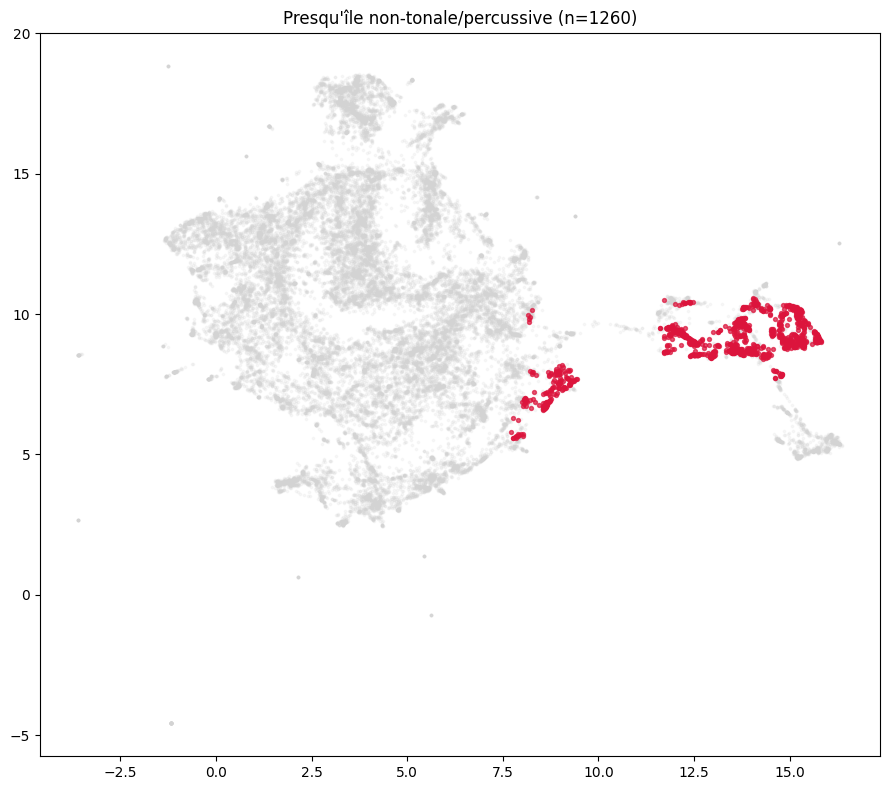

Copied 8 files to /u/anasynth/longeot/to_download

--- 8 fichiers exportes vers ~/to_download/ pour ecoute ---

--- Ecoute directe de 8 exemples ---
UID 15 - -BRUSHES-  (INCONI19)


UID 17 - BS&SNR-T0M (INCONI19)


UID 18 - BS&SNR-TM2 (INCONI19)


UID 19 - BS&SNR-TM2 (INCONI19)


UID 20 - BS&SNR-TM2 (INCONI19)


UID 27 - BUBBLEDRUM (INCONI19)


UID 29 -   BURDEL   (INCONI19)


UID 73 - CHROMA   5 (INCONI25)


In [178]:
peninsula_ids = [0, 3, 4]
mask_peninsula_main = np.isin(sub_labels, peninsula_ids)
peninsula_uids = main_uids[mask_peninsula_main]
print(f"=== Presqu'île non-tonale/percussive : {mask_peninsula_main.sum()} presets "
      f"(sous-clusters {peninsula_ids}) ===\n")

print("--- Composition par categorie (point_zone_display) ---")
print(zone_main[mask_peninsula_main].value_counts())

print("\n--- Features les plus distinctives (presqu'île vs reste du dataset, ecart normalise) ---")
mask_rest = ~behaviour_df.index.isin(peninsula_uids)
mean_pen = behaviour_df.loc[peninsula_uids, selected_38].mean()
mean_rest = behaviour_df.loc[mask_rest, selected_38].mean()
std_rest = behaviour_df.loc[mask_rest, selected_38].std()
diff_z = ((mean_pen - mean_rest) / std_rest).sort_values(key=abs, ascending=False)
print(diff_z.head(10))

# Visualisation sur l'UMAP complet
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(X38u[:, 0], X38u[:, 1], s=3, alpha=0.15, color='lightgray', zorder=1)
mask_full = behaviour_df.index.isin(peninsula_uids)
ax.scatter(X38u[mask_full, 0], X38u[mask_full, 1], s=8, alpha=0.7, color='crimson', zorder=2)
ax.set_title(f"Presqu'île non-tonale/percussive (n={mask_peninsula_main.sum()})")
plt.tight_layout(); plt.show()

# Export + ecoute directe de quelques exemples
sample_peninsula = list(peninsula_uids[:8])
copied = export_for_download(sample_peninsula)
print(f"\n--- {len(copied)} fichiers exportes vers ~/to_download/ pour ecoute ---")

print("\n--- Ecoute directe de 8 exemples ---")
for uid in sample_peninsula:
    name = db.get_preset_name(uid, long_name=True)
    path = wav_path(uid, 0)
    audio, sr = sf.read(path)
    print(f"UID {uid} - {name}")
    display(Audio(audio, rate=sr))


In [42]:
# ============================================================
# Investigation du cluster détaché sur la carte UMAP de Z
# ============================================================

# 1. Cluster isole via HDBSCAN dans l'espace natif 38D (cf. 14.1), plus robuste que des bornes
#    codees en dur sur l'embedding UMAP
detached_uids = behaviour_df.index[mask_detached]
print(f"=== {len(detached_uids)} presets dans le cluster détaché ===\n")

# 2. Noms des presets
print("--- Noms des presets (20 premiers) ---")
for uid in list(detached_uids[:20]):
    name = db.get_preset_name(uid, long_name=True)
    print(f"  {uid:6d}  {name}")

# 3. Catégories dominantes
print("\n--- Catégories de noms dominantes ---")
detached_cats = cat_labels.reindex(detached_uids)
print(detached_cats.value_counts())

# 4. Features qui distinguent le plus ce cluster du reste du dataset
print("\n--- Features les plus distinctives (écart cluster vs global, normalisé) ---")
mean_detached = behaviour_df.loc[detached_uids, selected_38].mean()
mean_global = behaviour_df[selected_38].mean()
std_global = behaviour_df[selected_38].std()
diff_z = ((mean_detached - mean_global) / std_global).sort_values(key=abs, ascending=False)
print(diff_z.head(10))

# 5. Export de quelques exemples pour écoute
sample_detached = list(detached_uids[:10])
copied = export_for_download(sample_detached)
print(f"\n--- {len(copied)} fichiers exportés vers ~/to_download/ pour écoute ---")
print("Depuis ton poste local : scp 'bonsho:~/to_download/*.wav' ~/dexed_listen_detached/")

=== 398 presets dans le cluster détaché ===

--- Noms des presets (20 premiers) ---
     313   BELLA 2   (CHROMA12)
     353  DISGUSTING (INCONI30)
     439  BOOM-GONG  (INCONI18)
     967  CYMPLOSION (INCONI27)
     968  CYMPLOSION (INCONI27)
    1483   FACTORY   (INCONI36)
    1522  Buzz     1 (INCONI20)
    1771   CLAV ENS  (CHROMA03)
    2103  CRASH CYMB (PERCUS03)
    2242  SUMO BELCH (INCONI91)
    2257  --XCOMPUTE (INCON108)
    2287  ANLG STG 6 (SYNTH-28)
    2288  ANLG SYNC1 (SYNTH-28)
    2482  REFS WHISL (WIND--05)
    2606  STOCKHAUSN (INCONI90)
    2622  SNAKE-WHL  (INCONI84)
    3033  HANFULOMTL (INCONI45)
    3093  SPACE NOS2 (INCONI86)
    3115  SPACENOIS3 (INCONI86)
    3219  ST.HELENS  (VOICES07)

--- Catégories de noms dominantes ---
OTHER            287
STRINGS           33
BASS              13
BELL              12
SYNTH             11
ENSEMBLE           8
HIHAT              7
PAD                7
VOICE              3
PERC               3
GUITAR             3
FLUTE 

Copied 10 files to /u/anasynth/longeot/to_download

--- 10 fichiers exportés vers ~/to_download/ pour écoute ---
Depuis ton poste local : scp 'bonsho:~/to_download/*.wav' ~/dexed_listen_detached/


In [181]:
# ============================================================
# Analyse complémentaire du cluster détaché
# ============================================================

# 1. Tous les noms uniques (pas que les 20 premiers), pour voir la vraie diversité
all_names_detached = [db.get_preset_name(uid, long_name=False) for uid in detached_uids]
name_words = Counter()
for name in all_names_detached:
    words = re.findall(r'[A-Z]+', name.upper())
    name_words.update(words)
print("--- Mots les plus fréquents dans le cluster détaché ---")
for word, count in name_words.most_common(25):
    print(f"  {word:15s} {count}")

# 2. Sous-structure interne : le cluster est-il homogène ou a-t-il des sous-groupes ?
#    (rapide coup d'oeil sur la dispersion interne de quelques features clés)
print("\n--- Dispersion interne du cluster (std) vs globale ---")
for feat in ['tt_F0_med', 'tt_SpecFlat_med', 'tt_SpecVar_med', 'tt_DecSlope']:
    std_in = behaviour_df.loc[detached_uids, feat].std()
    std_global = behaviour_df[feat].std()
    print(f"  {feat:20s} cluster std={std_in:.3f}  global std={std_global:.3f}")

# 3. Charger et écouter directement dans le notebook (sans passer par scp)
print("\n--- Écoute directe de 8 exemples ---")
sample_listen = list(detached_uids[:8])
for uid in sample_listen:
    name = db.get_preset_name(uid, long_name=True)
    path = wav_path(uid, 0)
    audio, sr = sf.read(path)
    print(f"UID {uid} - {name}")
    display(Audio(audio, rate=sr))

--- Mots les plus fréquents dans le cluster détaché ---
  HI              10
  WAVE            9
  EXPLOSION       8
  STRINGS         8
  IMAGE           8
  OCEAN           7
  ENS             6
  ANLG            6
  S               6
  WIND            6
  BELCH           5
  SYN             5
  LYTENING        5
  ANALOG          5
  EFX             5
  PLANE           5
  STRGS           5
  PAD             5
  SAMBA           4
  TYPEWRITER      4
  BELL            4
  SOUND           4
  SND             4
  WARMPAD         4
  GONG            3

--- Dispersion interne du cluster (std) vs globale ---
  tt_F0_med            cluster std=0.000  global std=0.997
  tt_SpecFlat_med      cluster std=1.309  global std=0.969
  tt_SpecVar_med       cluster std=0.651  global std=0.993
  tt_DecSlope          cluster std=0.222  global std=0.995

--- Écoute directe de 8 exemples ---
UID 313 -  BELLA 2   (CHROMA12)


UID 353 - DISGUSTING (INCONI30)


UID 439 - BOOM-GONG  (INCONI18)


UID 967 - CYMPLOSION (INCONI27)


UID 968 - CYMPLOSION (INCONI27)


UID 1483 -  FACTORY   (INCONI36)


UID 1522 - Buzz     1 (INCONI20)


UID 1771 -  CLAV ENS  (CHROMA03)


### 14.5 Checking the `tt_F0_med` degenerate-value hypothesis

`tt_F0_med` has a std of exactly 0.000 inside the detached cluster (vs 0.997 globally) --
suspiciously perfect. This checks the *raw* (pre log/z-score) TimbreToolbox value directly
from `raw_df`, to see whether it really is a single fallback/default value (a sign the F0
extractor fails silently on these non-tonal presets) rather than a genuine acoustic
property shared by the group.

In [43]:
print("--- tt_F0_med apres log+z-score (behaviour_df), sur le cluster detache ---")
print(behaviour_df.loc[detached_uids, 'tt_F0_med'].describe())

print("\n--- tt_F0_med brut (avant log+z-score), via raw_df, variation 0 ---")
raw_f0 = raw_df[(raw_df['preset_UID'].isin(detached_uids)) & (raw_df['variation'] == 0)][['preset_UID', 'tt_F0_med']]
print(raw_f0['tt_F0_med'].describe())

n_unique = raw_f0['tt_F0_med'].nunique()
print(f"\nNombre de valeurs distinctes de tt_F0_med (brut) dans le cluster: {n_unique} / {len(raw_f0)} presets")
print("Valeurs distinctes (jusqu'a 20):", sorted(raw_f0['tt_F0_med'].unique())[:20])

print("\n--- Pour comparaison, tt_F0_med brut sur le reste du dataset ---")
raw_f0_rest = raw_df[(~raw_df['preset_UID'].isin(detached_uids)) & (raw_df['variation'] == 0)]['tt_F0_med']
print(raw_f0_rest.describe())

if n_unique == 1:
    print(f"\n=> CONFIRME : tt_F0_med brut est une valeur CONSTANTE unique ({raw_f0['tt_F0_med'].iloc[0]}) "
          f"pour les {len(raw_f0)} presets du cluster -- artefact de repli de l'extracteur F0 "
          f"de TimbreToolbox sur des sons non-tonaux, pas une vraie propriete acoustique partagee.")
else:
    print(f"\n=> Pas une constante stricte ({n_unique} valeurs distinctes) -- a examiner plus finement "
          f"(peut-etre une plage tres etroite plutot qu'un artefact de repli).")


--- tt_F0_med apres log+z-score (behaviour_df), sur le cluster detache ---
count    398.000000
mean      -4.583427
std        0.000000
min       -4.583427
25%       -4.583427
50%       -4.583427
75%       -4.583427
max       -4.583427
Name: tt_F0_med, dtype: float64

--- tt_F0_med brut (avant log+z-score), via raw_df, variation 0 ---
count    398.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: tt_F0_med, dtype: float64

Nombre de valeurs distinctes de tt_F0_med (brut) dans le cluster: 1 / 398 presets
Valeurs distinctes (jusqu'a 20): [0.0]

--- Pour comparaison, tt_F0_med brut sur le reste du dataset ---
count    29738.000000
mean       184.379949
std         94.948812
min          0.000000
25%        104.003900
50%        207.519500
75%        208.007800
max        501.953100
Name: tt_F0_med, dtype: float64

=> CONFIRME : tt_F0_med brut est une valeur CONSTANTE unique (0.0) pour les 398 presets du cluster -- artefact de r

## 15. Next steps

- Once the full-dataset (30k presets) TT+ACTM computation finishes on `bonsho`, reload `raw_timbre_features.df.pickle`
  here and re-run sections 4-5 on the complete behaviour space.
- Quantify coverage (convex hull area, grid-cell occupancy, nearest-neighbour distances) as the baseline
  to compare against IMGEP-guided exploration.
- Compare this canonical 38-feature map against the earlier librosa-only map (section 3) to check whether
  the same dense/sparse regions appear in both.